In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import re
import lingam
import networkx as nx
import requests
import shap
import json


from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.dates import DateFormatter
from dotenv import load_dotenv
from collections import defaultdict
from IPython.display import display, Markdown
from datetime import datetime
from collections import Counter
from pprint import pprint

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
)

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")


print("✅ Imports loaded successfully!")


import warnings

warnings.filterwarnings("ignore")

✅ Imports loaded successfully!


In [ ]:
# Get all CSV files from the ../../data/machines folder
csv_files = glob.glob("../../data/azure_pm/machines/*.csv")

# Read each CSV file and create dataframes with the same name as the file
for file_path in csv_files:
    # Extract filename without extension
    file_name = os.path.splitext(os.path.basename(file_path))[0]

    # Read CSV and assign to variable with the same name as the file
    globals()[file_name] = pd.read_csv(file_path)

    print(f"Loaded {file_name}.csv with shape: {globals()[file_name].shape}")

In [3]:
# machine_1.head()
# machine_98.head()

In [4]:
machine_1.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,failure
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0,0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,0,0,0


<br> <br>

## Data Encoding and Scaling

In [ ]:
def encode_and_scale_dataframe(
    df,
    target_column="failure",
    categorical_cols=["model"],
    numerical_cols=["age", "volt", "pressure", "vibration"],
    scaling_method="minmax",
    exclude_features=None,
    remove_excluded=False,
):

    # Handle exclude_features parameter
    if exclude_features is None:
        exclude_features = []
    elif isinstance(exclude_features, str):
        exclude_features = [exclude_features]

    # Create a copy to avoid modifying original dataframe
    df_processed = df.copy()

    print("🔄 Starting encoding and scaling process...")
    print(f"📊 Original dataframe shape: {df_processed.shape}")

    if exclude_features:
        print(f"🚫 Excluding features from processing: {exclude_features}")
        if remove_excluded:
            print(f"🗑️  Features will be removed from output dataframe")

    # Dictionary to store encoders for later use
    encoders = {}

    # 1. ENCODE CATEGORICAL VARIABLES
    print("\n1️⃣ ENCODING CATEGORICAL VARIABLES")
    print("-" * 40)

    # Filter out excluded features from categorical columns
    categorical_cols_to_process = [
        col for col in categorical_cols if col not in exclude_features
    ]
    excluded_categorical = [col for col in categorical_cols if col in exclude_features]

    if excluded_categorical:
        print(f"   🚫 Skipping categorical encoding for: {excluded_categorical}")

    for col in categorical_cols_to_process:
        if col in df_processed.columns:
            print(f"   Encoding '{col}'...")

            # Create and fit label encoder
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))

            # Store encoder for future use
            encoders[col] = le

            # Display encoding mapping
            unique_values = df[col].unique()
            encoded_values = le.transform(unique_values.astype(str))
            mapping = dict(zip(unique_values, encoded_values))

            print(f"   ✅ {col} encoded: {mapping}")
        else:
            print(f"   ⚠️  Column '{col}' not found in dataframe")

    # 2. ENCODE TARGET VARIABLE (FAILURE)
    print(f"\n2️⃣ ENCODING TARGET VARIABLE: '{target_column}'")
    print("-" * 40)

    if target_column in exclude_features:
        print(f"   🚫 Skipping target variable encoding (excluded): '{target_column}'")
    elif target_column in df_processed.columns:
        print(f"   Encoding '{target_column}'...")

        # Check if target is already numeric
        if df_processed[target_column].dtype in ["object", "category"]:
            le_target = LabelEncoder()
            df_processed[target_column] = le_target.fit_transform(
                df_processed[target_column].astype(str)
            )
            encoders[target_column] = le_target

            # Display target encoding mapping
            unique_targets = df[target_column].unique()
            encoded_targets = le_target.transform(unique_targets.astype(str))
            target_mapping = dict(zip(unique_targets, encoded_targets))
            print(f"   ✅ {target_column} encoded: {target_mapping}")
        else:
            print(f"   ℹ️  {target_column} is already numeric")
    else:
        print(f"   ⚠️  Target column '{target_column}' not found")

    # 3. SCALE NUMERICAL FEATURES
    print(f"\n3️⃣ SCALING NUMERICAL FEATURES ({scaling_method.upper()})")
    print("-" * 40)

    # Filter out excluded features from numerical columns
    numerical_cols_to_process = [
        col for col in numerical_cols if col not in exclude_features
    ]
    excluded_numerical = [col for col in numerical_cols if col in exclude_features]

    if excluded_numerical:
        print(f"   🚫 Skipping scaling for: {excluded_numerical}")

    # Filter numerical columns that exist in dataframe
    existing_numerical_cols = [
        col for col in numerical_cols_to_process if col in df_processed.columns
    ]
    missing_numerical_cols = [
        col for col in numerical_cols_to_process if col not in df_processed.columns
    ]

    if missing_numerical_cols:
        print(f"   ⚠️  Missing columns: {missing_numerical_cols}")

    if existing_numerical_cols:
        print(f"   Scaling columns: {existing_numerical_cols}")

        # Choose scaler
        if scaling_method.lower() == "standard":
            scaler = StandardScaler()
            print("   📏 Using StandardScaler (mean=0, std=1)")
        elif scaling_method.lower() == "minmax":
            scaler = MinMaxScaler()
            print("   📏 Using MinMaxScaler (range 0-1)")
        else:
            scaler = StandardScaler()
            print("   📏 Default: Using StandardScaler")

        # Apply scaling
        df_processed[existing_numerical_cols] = scaler.fit_transform(
            df_processed[existing_numerical_cols]
        )

        print("   ✅ Scaling completed")

        # Display scaling statistics
        print("\n   📊 SCALING STATISTICS:")
        for col in existing_numerical_cols:
            original_mean = df[col].mean()
            original_std = df[col].std()
            scaled_mean = df_processed[col].mean()
            scaled_std = df_processed[col].std()

            print(
                f"   {col:12} | Original: μ={original_mean:6.2f}, σ={original_std:6.2f} | "
                f"Scaled: μ={scaled_mean:6.2f}, σ={scaled_std:6.2f}"
            )
    else:
        scaler = None
        print("   ⚠️  No numerical columns to scale")

    # 4. REMOVE EXCLUDED FEATURES (if requested)
    if remove_excluded and exclude_features:
        print(f"\n🗑️  REMOVING EXCLUDED FEATURES")
        print("-" * 40)
        features_to_remove = [
            col for col in exclude_features if col in df_processed.columns
        ]
        if features_to_remove:
            df_processed = df_processed.drop(columns=features_to_remove)
            print(f"   Removed columns: {features_to_remove}")
        else:
            print("   No excluded features found in dataframe")

    # 5. SUMMARY
    print(f"\n{'5️⃣' if remove_excluded else '4️⃣'} PROCESSING SUMMARY")
    print("-" * 40)
    print(f"   📊 Final dataframe shape: {df_processed.shape}")
    print(
        f"   🔤 Categorical columns encoded: {len([col for col in categorical_cols_to_process if col in encoders])}"
    )
    print(
        f"   🔢 Numerical columns scaled: {len(existing_numerical_cols) if existing_numerical_cols else 0}"
    )
    print(f"   🚫 Features excluded from processing: {len(exclude_features)}")
    if remove_excluded and exclude_features:
        print(
            f"   🗑️  Features removed from dataframe: {len([col for col in exclude_features if col in df.columns])}"
        )
    print(
        f"   🎯 Target variable processed: {'Yes' if target_column in df_processed.columns and target_column not in exclude_features else 'No'}"
    )

    return df_processed, encoders, scaler

In [ ]:
# Create a dictionary of all machine dataframes
machine_dataframes = {}

# Get a list of variable names first to avoid iteration issues
var_names = list(globals().keys())

for var_name in var_names:
    if var_name.startswith("machine_") and isinstance(
        globals()[var_name], pd.DataFrame
    ):
        machine_dataframes[var_name] = globals()[var_name]

# Apply encoding and scaling to all machine dataframes
processed_machine_dataframes = {}
encoders_dict = {}
scalers_dict = {}

print(f"Processing {len(machine_dataframes)} machine dataframes...")
print("=" * 60)

for machine_key, machine_df in machine_dataframes.items():
    print(f"\n🔧 Processing {machine_key}...")

    # Apply encoding and scaling
    processed_df, encoders, scaler = encode_and_scale_dataframe(
        df=machine_df,
        target_column="failure",
        categorical_cols=["errorID", "comp"],
        numerical_cols=["volt", "rotate", "pressure", "vibration"],
        scaling_method="minmax",
        # exclude_features=['machineID', "age", "model"],
        exclude_features=None,
        remove_excluded=True,
    )

    # Store processed dataframe and encoders/scalers
    processed_machine_dataframes[machine_key] = processed_df
    encoders_dict[machine_key] = encoders
    scalers_dict[machine_key] = scaler

    print(f"✅ {machine_key} processed successfully - Shape: {processed_df.shape}")

print(f"\n🎉 All {len(processed_machine_dataframes)} machine dataframes processed!")
print(f"📊 Total processed dataframes: {len(processed_machine_dataframes)}")

In [7]:
processed_machine_dataframes["machine_78"]

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,failure
0,2015-01-01 06:00:00,78,0.438956,0.662899,0.350619,0.430345,model4,19,0,0,0
1,2015-01-01 07:00:00,78,0.661957,0.492798,0.621244,0.476212,model4,19,0,0,0
2,2015-01-01 08:00:00,78,0.503096,0.481216,0.374924,0.407083,model4,19,0,0,0
3,2015-01-01 09:00:00,78,0.490425,0.673813,0.421443,0.274281,model4,19,0,0,0
4,2015-01-01 10:00:00,78,0.598596,0.330355,0.340109,0.143398,model4,19,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
8764,2016-01-01 02:00:00,78,0.747171,0.546129,0.428722,0.747210,model4,19,0,0,0
8765,2016-01-01 03:00:00,78,0.653613,0.506964,0.293624,0.493158,model4,19,0,0,0
8766,2016-01-01 04:00:00,78,0.483425,0.605971,0.312658,0.227458,model4,19,0,0,0
8767,2016-01-01 05:00:00,78,0.590948,0.562484,0.323725,0.517991,model4,19,0,0,0


<br> <br> <br>

### Create lag features

In [ ]:
## Fixed Temporal Feature Engineering with Categorical Target


def create_lag_features(df, target_col="failure", prediction_horizon=24):
    """
    Create lag features and CATEGORICAL target for time series prediction with NO future data leakage.

    Args:
        df: Input dataframe sorted by datetime
        target_col: Column containing failure information (categorical)
        prediction_horizon: Hours ahead to predict (default: 24 hours)

    Returns:
        DataFrame with lag features and proper CATEGORICAL target variable
    """
    print(
        f"🔄 Creating lag features and CATEGORICAL target (predicting {prediction_horizon}h ahead)..."
    )
    print(f"Original target distribution: {df[target_col].value_counts().to_dict()}")

    # Ensure data is sorted by time
    df_sorted = df.sort_values("datetime").reset_index(drop=True)

    # Keep failure as categorical (no conversion to binary)
    print(
        f"Categorical failure distribution: {df_sorted[target_col].value_counts().to_dict()}"
    )
    print(f"Unique failure types: {sorted(df_sorted[target_col].unique())}")

    # Create target: predict failure type within next N hours using forward-looking window
    # For categorical data, we'll take the maximum failure type in the next N hours
    df_sorted["target"] = (
        df_sorted[target_col]
        .rolling(window=prediction_horizon, min_periods=1)
        .max()
        .shift(-prediction_horizon)
        .fillna(0)
    )

    # Ensure target maintains the same data type as original failure column
    df_sorted["target"] = df_sorted["target"].astype(df_sorted[target_col].dtype)

    display(df_sorted["target"].value_counts())

    # Remove last N rows where we can't predict the future
    df_sorted = df_sorted.iloc[:-prediction_horizon].copy()

    # Create lag features for sensor data (only use PAST data)
    sensor_cols = ["volt", "rotate", "pressure", "vibration"]

    print(f"Creating lag features for sensor columns: {sensor_cols}")

    for col in sensor_cols:
        # Lag features (1, 6, 12, 24 hours ago)
        for lag in [1, 6, 12, 24]:
            df_sorted[f"{col}_lag_{lag}h"] = df_sorted[col].shift(lag)

        # Rolling statistics (past 24 hours)
        df_sorted[f"{col}_mean_24h"] = (
            df_sorted[col].rolling(window=24, min_periods=1).mean()
        )
        df_sorted[f"{col}_std_24h"] = (
            df_sorted[col].rolling(window=24, min_periods=1).std()
        )
        df_sorted[f"{col}_min_24h"] = (
            df_sorted[col].rolling(window=24, min_periods=1).min()
        )
        df_sorted[f"{col}_max_24h"] = (
            df_sorted[col].rolling(window=24, min_periods=1).max()
        )

        # Rolling statistics (past 6 hours)
        df_sorted[f"{col}_mean_6h"] = (
            df_sorted[col].rolling(window=6, min_periods=1).mean()
        )
        df_sorted[f"{col}_std_6h"] = (
            df_sorted[col].rolling(window=6, min_periods=1).std()
        )

    # Error and maintenance lag features
    df_sorted["errorID_lag_1h"] = df_sorted["errorID"].shift(1)
    df_sorted["errorID_lag_6h"] = df_sorted["errorID"].shift(6)
    df_sorted["errorID_lag_12h"] = df_sorted["errorID"].shift(12)
    df_sorted["comp_lag_1h"] = df_sorted["comp"].shift(1)
    df_sorted["comp_lag_6h"] = df_sorted["comp"].shift(6)
    df_sorted["comp_lag_12h"] = df_sorted["comp"].shift(12)

    # Count features (past events only)
    df_sorted["error_count_6h"] = (
        df_sorted["errorID"].rolling(window=6, min_periods=1).sum()
    )
    df_sorted["error_count_24h"] = (
        df_sorted["errorID"].rolling(window=24, min_periods=1).sum()
    )
    df_sorted["maint_count_6h"] = (
        df_sorted["comp"].rolling(window=6, min_periods=1).sum()
    )
    df_sorted["maint_count_24h"] = (
        df_sorted["comp"].rolling(window=24, min_periods=1).sum()
    )

    # Time features
    df_sorted["hour"] = df_sorted["datetime"].dt.hour
    df_sorted["day_of_week"] = df_sorted["datetime"].dt.dayofweek
    df_sorted["is_weekend"] = (df_sorted["datetime"].dt.dayofweek >= 5).astype(int)
    df_sorted["is_working_hours"] = (
        (df_sorted["hour"] >= 8) & (df_sorted["hour"] <= 17)
    ).astype(int)

    # Hours since last maintenance
    maint_mask = df_sorted["comp"] > 0
    if maint_mask.any():
        last_maint_idx = -1
        hours_since_maint = []
        for i, is_maint in enumerate(maint_mask):
            if is_maint:
                last_maint_idx = i
                hours_since_maint.append(0)
            else:
                hours_since_maint.append(
                    i - last_maint_idx if last_maint_idx >= 0 else i
                )
        df_sorted["hours_since_maint"] = hours_since_maint
    else:
        df_sorted["hours_since_maint"] = range(len(df_sorted))

    # Hours since last error
    error_mask = df_sorted["errorID"] > 0
    if error_mask.any():
        last_error_idx = -1
        hours_since_error = []
        for i, is_error in enumerate(error_mask):
            if is_error:
                last_error_idx = i
                hours_since_error.append(0)
            else:
                hours_since_error.append(
                    i - last_error_idx if last_error_idx >= 0 else i
                )
        df_sorted["hours_since_error"] = hours_since_error
    else:
        df_sorted["hours_since_error"] = range(len(df_sorted))

    # Fill NaN values created by lag features
    df_sorted = df_sorted.fillna(0)

    print(f"✅ Created lag features. Final shape: {df_sorted.shape}")
    print(
        f"   CATEGORICAL Target distribution: {df_sorted['target'].value_counts().to_dict()}"
    )
    print(f"   Target classes: {sorted(df_sorted['target'].unique())}")
    print(f"   Target data type: {df_sorted['target'].dtype}")
    print(
        f"   New feature count: {len([col for col in df_sorted.columns if col not in df.columns])}"
    )

    return df_sorted

In [ ]:
# Apply lag feature engineering to all processed machine dataframes
lag_machine_dataframes = {}

print(
    f"Creating lag features for {len(processed_machine_dataframes)} machine dataframes..."
)
print("=" * 70)

for machine_key, processed_df in processed_machine_dataframes.items():
    print(f"\n🔧 Processing {machine_key}...")

    # Get the original machine dataframe to access datetime column
    original_df = machine_dataframes[machine_key].copy()

    # Add datetime back to processed dataframe for lag feature creation
    processed_df_with_datetime = processed_df.copy()
    processed_df_with_datetime["datetime"] = original_df["datetime"].values

    # Convert datetime column to proper datetime format
    processed_df_with_datetime["datetime"] = pd.to_datetime(
        processed_df_with_datetime["datetime"]
    )

    # Apply lag feature engineering
    df_with_lags = create_lag_features(
        df=processed_df_with_datetime,
        target_col="failure",
        # prediction_horizon=24,
        prediction_horizon=2,
    )

    # Store the result
    lag_machine_dataframes[machine_key] = df_with_lags

    print(f"✅ {machine_key} lag features created - Shape: {df_with_lags.shape}")

print(
    f"\n🎉 All {len(lag_machine_dataframes)} machine dataframes processed with lag features!"
)
print(f"📊 Total lag dataframes created: {len(lag_machine_dataframes)}")

# Display sample from one machine
sample_machine = "machine_100"
if sample_machine in lag_machine_dataframes:
    print(f"\n📋 Sample from {sample_machine}:")
    print(
        f"Columns ({len(lag_machine_dataframes[sample_machine].columns)}): {list(lag_machine_dataframes[sample_machine].columns)}"
    )
    print(f"Shape: {lag_machine_dataframes[sample_machine].shape}")

## Temporal Feature Engineering for Predictive Maintenance

The transformation of raw time-series sensor data into a structured format suitable for machine learning models necessitated a comprehensive temporal feature engineering approach. This process was essential to capture the temporal dependencies and historical patterns inherent in industrial machinery behavior, enabling the models to learn from past observations to predict future failure events.

### Rationale for Temporal Feature Engineering

Industrial machinery operates in complex temporal patterns where current system states are heavily influenced by historical operating conditions, maintenance activities, and error occurrences. Simple cross-sectional analysis of instantaneous sensor readings fails to capture the degradation processes, cyclical patterns, and cumulative effects that precede equipment failures. Therefore, a systematic approach to temporal feature extraction was implemented to provide predictive models with rich historical context while maintaining strict temporal causality to prevent data leakage.

### Target Variable Construction

The primary prediction task was formulated as a multi-class classification problem with a 24-hour prediction horizon. For each temporal observation, a forward-looking window of 24 hours was examined to identify the most severe failure event within this future timeframe. The target variable was constructed by taking the maximum failure severity code observed in the subsequent 24-hour period, with zero assigned to periods where no failure occurred. This approach ensures that the model learns to recognize precursor patterns that manifest up to 24 hours before actual failure events. To maintain temporal integrity, the final 24 observations of each machine's dataset were excluded from analysis, as complete future windows could not be constructed for these instances.

### Historical Sensor Feature Engineering

A multi-scale temporal feature extraction strategy was employed to capture both short-term fluctuations and longer-term trends in sensor measurements. For each primary sensor variable—voltage, rotation speed, pressure, and vibration—several categories of historical features were systematically constructed:

**Discrete Lag Features**: Direct lagged values were extracted at strategically selected intervals of 1, 6, 12, and 24 hours prior to each observation. This approach captures the immediate operational history and enables the model to identify specific temporal patterns associated with impending failures.

**Rolling Window Statistics**: To characterize the statistical behavior of sensor readings over time, comprehensive statistical metrics were computed over sliding historical windows. For each sensor, the mean, standard deviation, minimum, and maximum values were calculated over both 6-hour and 24-hour retrospective periods. These features effectively capture operational trends, variability patterns, and extreme value occurrences that may indicate developing anomalies.

### Event-Based Temporal Features

Given the discrete nature of maintenance activities and error occurrences, specialized features were engineered to capture the temporal relationships between these events and system failures. Historical values of categorical event variables, including error codes and maintenance component identifiers, were extracted at 1, 6, and 12-hour lag intervals. Additionally, cumulative event frequency features were computed by counting the total number of error occurrences and maintenance activities within rolling 6-hour and 24-hour windows, providing insight into the intensity of recent operational disturbances.

### Operational Context Features

To account for temporal patterns related to operational scheduling and human factors, several time-derived contextual features were incorporated. These included the hour of the day, day of the week, and binary indicators for weekend periods and standard working hours (08:00-17:00). Such features enable the model to account for systematic variations in operational patterns and maintenance practices that occur across different temporal cycles.

### Time-Since-Event Features

Two critical temporal distance features were engineered to quantify the elapsed time since significant operational events. The time since the last maintenance activity and the time since the last error occurrence were calculated for each observation, providing the model with explicit information about the operational state relative to these critical events. These features are particularly valuable for capturing the deterioration patterns that develop between maintenance cycles and the escalation patterns that may follow initial error manifestations.

### Missing Value Treatment

The temporal feature engineering process inherently generates missing values at the beginning of each machine's time series due to the unavailability of sufficient historical data for lag and rolling window calculations. These missing values were systematically imputed with zeros, representing a neutral baseline that does not bias the model while maintaining the temporal structure of the dataset.

This comprehensive temporal feature engineering approach transforms the raw time-series data into a rich, multi-dimensional representation that captures the complex temporal dependencies essential for accurate predictive maintenance modeling, while rigorously maintaining temporal causality to ensure the validity of predictive insights.

<br> <br> <br>

#### Save lag features to /lag_features

In [10]:
# Save lag_machine_dataframes to ../../data/azure_pm/machines/lag_features

# Create the output directory if it doesn't exist
output_dir = "../../data/azure_pm/lag_features/"
os.makedirs(output_dir, exist_ok=True)

print(f"💾 Saving {len(lag_machine_dataframes)} lag feature dataframes...")
print("=" * 60)

# Save each lag feature dataframe
for machine_key, lag_df in lag_machine_dataframes.items():
    output_path = os.path.join(output_dir, f"{machine_key}_lag_features.csv")

    # Save to CSV
    lag_df.to_csv(output_path, index=False)

    print(f"✅ Saved {machine_key} - Shape: {lag_df.shape} - File: {output_path}")

print(f"\n🎉 All lag feature dataframes saved successfully!")
print(f"📁 Output directory: {output_dir}")
print(f"📊 Total files saved: {len(lag_machine_dataframes)}")

# Display directory contents
saved_files = [f for f in os.listdir(output_dir) if f.endswith("_lag_features.csv")]
print(f"\n📋 Saved files ({len(saved_files)}):")
for i, filename in enumerate(sorted(saved_files)[:10]):  # Show first 10
    print(f"  {i+1:2d}. {filename}")
if len(saved_files) > 10:
    print(f"  ... and {len(saved_files) - 10} more files")

💾 Saving 100 lag feature dataframes...
✅ Saved machine_1 - Shape: (8770, 68) - File: ../../data/azure_pm/lag_features/machine_1_lag_features.csv
✅ Saved machine_10 - Shape: (8773, 68) - File: ../../data/azure_pm/lag_features/machine_10_lag_features.csv
✅ Saved machine_100 - Shape: (8764, 68) - File: ../../data/azure_pm/lag_features/machine_100_lag_features.csv
✅ Saved machine_11 - Shape: (8769, 68) - File: ../../data/azure_pm/lag_features/machine_11_lag_features.csv
✅ Saved machine_12 - Shape: (8771, 68) - File: ../../data/azure_pm/lag_features/machine_12_lag_features.csv
✅ Saved machine_13 - Shape: (8779, 68) - File: ../../data/azure_pm/lag_features/machine_13_lag_features.csv
✅ Saved machine_14 - Shape: (8770, 68) - File: ../../data/azure_pm/lag_features/machine_14_lag_features.csv
✅ Saved machine_15 - Shape: (8773, 68) - File: ../../data/azure_pm/lag_features/machine_15_lag_features.csv
✅ Saved machine_16 - Shape: (8771, 68) - File: ../../data/azure_pm/lag_features/machine_16_lag_fe

<br> <br> <br>

# Create balanced dataset 


#### Single Sample

- The following methodology extracts one sample (one hour) at a fixed interval (e.g., 24 hours) before each failure is a perfectly valid and common approach.

- **What it does well:** It frames the problem as a classic binary classification task. You are asking the model a very clear question: "Given the machine's state at this specific hour, what is the probability of failure in the next 24 hours?" This is interpretable and works very well with powerful models like XGBoost, LightGBM, and Random Forest, which we are using.

- **The main limitation:** It is a static snapshot. The model sees the state at T-24 hours but has no direct information about the trend leading up to that point. For instance, it doesn't know if a pressure reading has been slowly climbing for 12 hours or if it just spiked in the last hour. This crucial dynamic information is lost.


In [ ]:
def rows_n_hours_before_failure(machine, machine_failure, hours):
    failure_times = machine_failure["datetime"]

    # Convert the datetime columns to datetime if they're not already
    machine["datetime"] = pd.to_datetime(machine["datetime"])
    failure_times = pd.to_datetime(failure_times)

    # Initialize an empty list to store the rows and their indices
    rows = []
    indices = []

    # Iterate over each failure time and its index
    for idx_failure, failure_time in zip(machine_failure.index, failure_times):
        # Calculate the time n hours before the failure
        target_time = failure_time - pd.Timedelta(hours=hours)

        # Get the row with the closest time to the target time
        idx = (machine["datetime"] - target_time).abs().idxmin()
        closest_row = machine.loc[idx]

        # Append the row and the failure index to the lists
        rows.append(closest_row)
        indices.append(idx_failure)

    # Create a new dataframe with the rows
    machine_1_prev_24h = pd.DataFrame(rows)
    machine_1_prev_24h["id_failure_row"] = indices

    return machine_1_prev_24h


def update_lag_failure_target(
    machine_failure, machine_n_hours_before_failure, lag_failure
):
    """
    Updates the 'target' variable in lag_failure with the corresponding 'failure' value from machine_failure,
    using machine_n_hours_before_failure as a bridge for the join.
    """
    if "id_failure_row" not in machine_n_hours_before_failure.columns:
        raise ValueError(
            "machine_n_hours_before_failure must have 'id_failure_row' column."
        )

    failure_values = []
    for idx in lag_failure.index:
        if idx in machine_n_hours_before_failure.index:
            id_failure_row = machine_n_hours_before_failure.loc[idx, "id_failure_row"]
            # If multiple rows, take the first
            if isinstance(id_failure_row, pd.Series):
                id_failure_row = id_failure_row.iloc[0]
            failure_val = (
                machine_failure.loc[id_failure_row, "failure"]
                if id_failure_row in machine_failure.index
                else None
            )
        else:
            failure_val = None
        failure_values.append(failure_val)

    lag_failure = lag_failure.copy()
    lag_failure["target"] = failure_values
    return lag_failure


def create_safe_non_failure_samples_enhanced(
    machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48
):
    """
    Create non-failure samples from 'safe zones' using the full feature set from machine_lag

    Parameters:
    - machine_lag: Full dataset with all engineered features
    - lag_failure_updated: Your target dataset (24h before failures)
    - hours_before: Lead time before failure (24h)
    - safe_buffer_hours: Additional buffer to ensure truly safe periods (48h recommended)
    """

    # Convert datetime columns to datetime if they aren't already
    machine_lag["datetime"] = pd.to_datetime(machine_lag["datetime"])
    lag_failure_updated["datetime"] = pd.to_datetime(lag_failure_updated["datetime"])

    # Get all failure timestamps from machine_lag where failure = 1
    failure_timestamps = machine_lag[machine_lag["failure"] == 1]["datetime"]

    # Create exclusion zones around each failure
    exclusion_periods = []

    for failure_time in failure_timestamps:
        # Exclude from (failure_time - safe_buffer_hours) to failure_time
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))

    # Also exclude the timestamps that are already in lag_failure_updated (24h before failures)
    existing_target_timestamps = set(lag_failure_updated["datetime"])

    # Filter machine_lag to find safe timestamps
    safe_candidates = machine_lag.copy()

    # Remove rows that fall in exclusion zones
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False

    # Filter out exclusion zones and existing target timestamps
    safe_mask = (
        ~safe_candidates["datetime"].apply(is_in_exclusion_zone)
        & ~safe_candidates["datetime"].isin(existing_target_timestamps)
        & (safe_candidates["failure"] == 0)  # Only non-failure records
    )

    safe_candidates = safe_candidates[safe_mask]

    if len(safe_candidates) == 0:
        print("Warning: No safe candidates found. Consider reducing safe_buffer_hours.")
        return pd.DataFrame()

    # Sample non-failure records
    n_samples = min(len(lag_failure_updated), len(safe_candidates))

    if n_samples > len(safe_candidates):
        print(
            f"Warning: Only {len(safe_candidates)} safe candidates available, but {len(lag_failure_updated)} samples requested."
        )
        n_samples = len(safe_candidates)

    # Randomly sample from safe candidates
    non_failure_samples = safe_candidates.sample(n=n_samples, random_state=42).copy()

    # Set target to 0 for non-failure samples (they should already be 0, but ensure it)
    non_failure_samples["target"] = 0

    # Reset index
    non_failure_samples = non_failure_samples.reset_index(drop=True)

    return non_failure_samples


def create_balanced_dataset(
    machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48
):
    """
    Create a balanced dataset combining failure predictions and safe non-failure samples
    """

    # Get non-failure samples
    non_failure_df = create_safe_non_failure_samples_enhanced(
        machine_lag, lag_failure_updated, hours_before, safe_buffer_hours
    )

    if len(non_failure_df) == 0:
        return lag_failure_updated.copy()

    # Ensure both dataframes have the same columns
    common_columns = list(
        set(lag_failure_updated.columns) & set(non_failure_df.columns)
    )

    # If lag_failure_updated is missing some features, we need to merge them from machine_lag
    if len(common_columns) < len(machine_lag.columns):
        print("Merging additional features from machine_lag to lag_failure_updated...")

        # Merge lag_failure_updated with machine_lag to get all features
        lag_failure_enhanced = pd.merge(
            lag_failure_updated,
            machine_lag,
            on="datetime",
            how="left",
            suffixes=("", "_from_machine_lag"),
        )

        # Clean up duplicate columns (keep the original values from lag_failure_updated)
        for col in lag_failure_enhanced.columns:
            if col.endswith("_from_machine_lag"):
                original_col = col.replace("_from_machine_lag", "")
                if original_col in lag_failure_enhanced.columns:
                    lag_failure_enhanced[original_col] = lag_failure_enhanced[
                        original_col
                    ].fillna(lag_failure_enhanced[col])
                    lag_failure_enhanced = lag_failure_enhanced.drop(columns=[col])

        lag_failure_to_use = lag_failure_enhanced
    else:
        lag_failure_to_use = lag_failure_updated.copy()

    # Ensure all required columns are present in both dataframes
    all_required_columns = list(machine_lag.columns)

    # Add missing columns with appropriate default values if needed
    for col in all_required_columns:
        if col not in lag_failure_to_use.columns:
            lag_failure_to_use[col] = np.nan
        if col not in non_failure_df.columns:
            non_failure_df[col] = np.nan

    # Select only the required columns in the same order
    lag_failure_to_use = lag_failure_to_use[all_required_columns]
    non_failure_df = non_failure_df[all_required_columns]

    # Combine datasets
    balanced_dataset = pd.concat(
        [lag_failure_to_use, non_failure_df], ignore_index=True
    )
    balanced_dataset = balanced_dataset.sort_values("datetime").reset_index(drop=True)

    return balanced_dataset, non_failure_df


# Alternative: If you want more control over sampling strategy
def create_stratified_non_failure_samples(
    machine_lag,
    lag_failure_updated,
    safe_buffer_hours=48,
    stratify_by=["comp", "is_weekend", "is_working_hours"],
):
    """
    Create stratified non-failure samples to ensure diversity across different conditions
    """

    machine_lag["datetime"] = pd.to_datetime(machine_lag["datetime"])
    lag_failure_updated["datetime"] = pd.to_datetime(lag_failure_updated["datetime"])

    # Get failure timestamps and create exclusion zones
    failure_timestamps = machine_lag[machine_lag["failure"] == 1]["datetime"]
    exclusion_periods = []

    for failure_time in failure_timestamps:
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))

    # Filter safe candidates
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False

    existing_target_timestamps = set(lag_failure_updated["datetime"])

    safe_mask = (
        ~machine_lag["datetime"].apply(is_in_exclusion_zone)
        & ~machine_lag["datetime"].isin(existing_target_timestamps)
        & (machine_lag["failure"] == 0)
    )

    safe_candidates = machine_lag[safe_mask].copy()

    if len(safe_candidates) == 0:
        return pd.DataFrame()

    # Stratified sampling
    target_samples = len(lag_failure_updated)

    # Get the distribution of stratification variables in lag_failure_updated
    if all(col in lag_failure_updated.columns for col in stratify_by):
        # Sample proportionally to match the failure sample distribution
        stratified_samples = []

        for group_values, group_df in lag_failure_updated.groupby(stratify_by):
            group_size = len(group_df)
            proportion = group_size / len(lag_failure_updated)
            target_group_size = int(proportion * target_samples)

            # Find matching safe candidates
            mask = pd.Series(True, index=safe_candidates.index)
            for i, col in enumerate(stratify_by):
                mask &= safe_candidates[col] == group_values[i]

            group_safe_candidates = safe_candidates[mask]

            if len(group_safe_candidates) > 0:
                sample_size = min(target_group_size, len(group_safe_candidates))
                group_sample = group_safe_candidates.sample(
                    n=sample_size, random_state=42
                )
                stratified_samples.append(group_sample)

        if stratified_samples:
            non_failure_samples = pd.concat(stratified_samples, ignore_index=True)
        else:
            # Fallback to random sampling
            non_failure_samples = safe_candidates.sample(
                n=min(target_samples, len(safe_candidates)), random_state=42
            )
    else:
        # Fallback to random sampling if stratification columns not available
        non_failure_samples = safe_candidates.sample(
            n=min(target_samples, len(safe_candidates)), random_state=42
        )

    non_failure_samples["target"] = 0

    return non_failure_samples.reset_index(drop=True)

In [12]:
# Loop through machine_number 1 to 100 and generate balanced datasets for each machine

hours_before_failure = 1
safe_buffer_hours = 48

balanced_datasets = {}
non_failure_dfs = {}

for machine_number in range(1, 101):
    try:
        # Load data for this machine
        machine = pd.read_csv(
            f"../../data/azure_pm/machines/machine_{machine_number}.csv"
        )
        machine_lag = pd.read_csv(
            f"../../data/azure_pm/lag_features/machine_{machine_number}_lag_features.csv"
        )

        # Identify failures
        machine_failure = machine[machine["failure"] != "0"]

        # Get rows n hours before each failure
        machine_n_hours_before_failure = rows_n_hours_before_failure(
            machine=machine, machine_failure=machine_failure, hours=hours_before_failure
        )
        lag_failure = rows_n_hours_before_failure(
            machine=machine_lag,
            machine_failure=machine_lag[machine_lag["failure"] != 0],
            hours=hours_before_failure,
        )

        # Update lag_failure target
        lag_failure_updated = update_lag_failure_target(
            machine_failure=machine_failure,
            machine_n_hours_before_failure=machine_n_hours_before_failure,
            lag_failure=lag_failure,
        )

        # Create balanced dataset
        balanced_dataset, non_failure_df = create_balanced_dataset(
            machine_lag=machine_lag,
            lag_failure_updated=lag_failure_updated,
            hours_before=hours_before_failure,
            safe_buffer_hours=safe_buffer_hours,
        )

        # Store results with machine number as key
        balanced_datasets[machine_number] = balanced_dataset
        non_failure_dfs[machine_number] = non_failure_df

        print(
            f"✅ Machine {machine_number}: Balanced dataset shape: {balanced_dataset.shape}, Non-failure shape: {non_failure_df.shape}"
        )

    except Exception as e:
        print(f"❌ Machine {machine_number}: Error - {e}")

✅ Machine 1: Balanced dataset shape: (22, 68), Non-failure shape: (11, 68)
✅ Machine 2: Balanced dataset shape: (12, 68), Non-failure shape: (6, 68)
✅ Machine 3: Balanced dataset shape: (10, 68), Non-failure shape: (5, 68)
✅ Machine 4: Balanced dataset shape: (14, 68), Non-failure shape: (7, 68)
✅ Machine 5: Balanced dataset shape: (20, 68), Non-failure shape: (10, 68)
❌ Machine 6: Error - 'datetime'
✅ Machine 7: Balanced dataset shape: (34, 68), Non-failure shape: (17, 68)
✅ Machine 8: Balanced dataset shape: (10, 68), Non-failure shape: (5, 68)
✅ Machine 9: Balanced dataset shape: (32, 68), Non-failure shape: (16, 68)
✅ Machine 10: Balanced dataset shape: (16, 68), Non-failure shape: (8, 68)
✅ Machine 11: Balanced dataset shape: (18, 68), Non-failure shape: (9, 68)
✅ Machine 12: Balanced dataset shape: (18, 68), Non-failure shape: (9, 68)
✅ Machine 13: Balanced dataset shape: (44, 68), Non-failure shape: (22, 68)
✅ Machine 14: Balanced dataset shape: (14, 68), Non-failure shape: (7, 

In [ ]:
# Join all balanced_datasets into a single DataFrame named df_union
df_union = pd.concat(
    [df for df in balanced_datasets.values() if not df.empty], ignore_index=True
)

# Optional: sort by datetime and reset index for consistency
df_union = df_union.sort_values(by="datetime").reset_index(drop=True)

df = df_union.copy()

# Apply mapping to target column so it's always integer
target_mapping = {
    "0": 0,
    0: 0,
    "comp1": 1,
    1: 1,
    "comp2": 2,
    2: 2,
    "comp3": 3,
    3: 3,
    "comp4": 4,
    4: 4,
}
df["target"] = df["target"].map(target_mapping).astype(int)

In [14]:
df.shape

(2244, 68)

#### Dataset Construction and Balancing Methodology

To develop a robust predictive maintenance model, a meticulously constructed and balanced dataset was generated from the raw time-series sensor data. The primary objectives of this procedure were to mitigate the inherent class imbalance between failure and non-failure states and, critically, to prevent data leakage by ensuring strict temporal separation between samples representing different classes.

The process began with the identification of positive class instances. For each documented failure event across the machine population, a corresponding data snapshot was extracted from a precise temporal window of 24 hours prior to the event. This set of instances constitutes the "pre-failure" or positive class, representing the system state leading up to a malfunction.

The construction of the negative class (i.e., instances of normal, healthy operation) was performed with particular rigor to avoid look-ahead bias. First, temporal "exclusion zones" were established around each failure event. These zones spanned a 48-hour period immediately preceding each failure, effectively quarantining any data that could potentially contain early, unobserved indicators of the impending fault.

Subsequently, candidate instances for the negative class were exclusively drawn from periods of operation outside of these exclusion zones and from periods not already labeled as pre-failure. From this pool of "safe" operational data, a set of non-failure instances was randomly sampled. The number of these sampled non-failure instances was deliberately matched to the total number of pre-failure instances to create a perfectly balanced 1:1 class ratio in the final dataset. This balancing is essential to prevent the classification model from developing a bias towards the majority (non-failure) class.

Finally, the collected pre-failure (positive) and safe-operation (negative) samples from all machines were aggregated and sorted chronologically by their timestamps. The resulting dataset is thus a chronologically coherent, balanced collection of samples, specifically engineered to provide a valid basis for training and evaluating time-series classification models while minimizing the risk of data leakage.

---

#### Dataset Construction and Balancing Methodology

To develop a robust predictive maintenance model, a meticulously constructed and balanced dataset was generated from the raw time-series sensor data with the primary objectives of mitigating inherent class imbalance and preventing data leakage. This process began with the identification of positive class instances by extracting a data snapshot from the precise 24-hour window preceding each documented failure event. The corresponding negative class was constructed with particular rigor to avoid look-ahead bias; temporal "exclusion zones" spanning the 48-hour period prior to each failure were established to quarantine any data containing potential early fault indicators. Subsequently, non-failure instances were randomly sampled exclusively from these "safe" operational periods in a quantity deliberately matched to the number of pre-failure instances, thereby creating a perfectly balanced 1:1 class ratio. Finally, all collected pre-failure and safe-operation samples were aggregated and sorted chronologically by their timestamps, yielding a temporally coherent dataset specifically engineered for valid time-series model training and evaluation.


In [15]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 20:00:00,7,0.631991,0.822745,0.431698,0.527483,model3,20,0,0,...,0.0,0.0,0.0,0.0,20,3,0,0,14,14
1,2015-01-02 02:00:00,17,0.428857,0.170647,0.164214,0.758246,model1,14,0,0,...,0.0,0.0,0.0,4.0,2,4,0,0,20,20
2,2015-01-02 02:00:00,79,0.751701,0.523797,0.368828,0.291526,model3,14,0,0,...,0.0,0.0,0.0,0.0,2,4,0,0,20,20
3,2015-01-02 02:00:00,73,0.422375,0.498530,0.765776,0.373949,model2,20,0,0,...,0.0,4.0,0.0,0.0,2,4,0,0,20,20
4,2015-01-02 02:00:00,83,0.348804,0.448234,0.435553,0.695304,model4,18,0,0,...,0.0,0.0,0.0,2.0,2,4,0,0,20,20


In [ ]:
def flexible_multi_column_plot_with_window_feature_move(
    df,
    target_col,
    columns_to_plot,
    failure_datetime,
    hours_before=168,
    hours_after=168,
    figsize=(12, 6),
    legend_location="upper right",
    show_hours=False,
    shift_features=None,
):
    """
    Enhanced plotting function for multiple columns with failure-centered time window and feature shifting capability

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with datetime index
    target_col : str
        Target variable column name for failure events
    columns_to_plot : list
        List of column names to plot
    failure_datetime : str or datetime
        The datetime when the failure occurred
    hours_before : int
        Number of hours before the failure to include in the plot
    hours_after : int
        Number of hours after the failure to include in the plot
    figsize : tuple
        Figure size (width, height)
    show_hours : bool
        If True, display hours in x-axis labels; if False, display only dates
    shift_features : dict or None
        Dictionary with feature names as keys and shift hours as values
        Positive values shift forward in time, negative values shift backward
        Example: {'vibration': 2, 'pressure': -1} shifts vibration 2 hours forward, pressure 1 hour backward

    Returns:
    --------
    fig : matplotlib figure
        The created figure
    """

    # Validate inputs
    if not isinstance(columns_to_plot, list) or len(columns_to_plot) == 0:
        print("Error: columns_to_plot must be a non-empty list")
        return None

    missing_cols = [col for col in columns_to_plot if col not in df.columns]
    if missing_cols:
        print(f"Error: Missing columns in dataframe: {missing_cols}")
        return None

    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found in dataframe")
        return None

    # Convert failure_datetime to pandas datetime if it's a string
    if isinstance(failure_datetime, str):
        failure_datetime = pd.to_datetime(failure_datetime)

    # Calculate time window using hours
    start_time = failure_datetime - pd.Timedelta(hours=hours_before)
    end_time = failure_datetime + pd.Timedelta(hours=hours_after)

    print(f"🎯 Failure Event: {failure_datetime}")
    print(f"📅 Time Window: {start_time} to {end_time}")
    print(
        f"⏱️  Total Window: {hours_before + hours_after} hours ({hours_before} before + {hours_after} after)"
    )

    # Filter dataframe to the specified time window
    df_window = df[(df.index >= start_time) & (df.index <= end_time)].copy()

    if len(df_window) == 0:
        print("Error: No data found in the specified time window")
        return None

    # Apply feature shifting if specified
    if shift_features:
        print(f"🔄 Applying feature shifts:")
        for feature, shift_hours in shift_features.items():
            if feature in df_window.columns and feature != target_col:
                print(
                    f"   📈 {feature}: {shift_hours:+d} hours ({'forward' if shift_hours > 0 else 'backward' if shift_hours < 0 else 'no shift'})"
                )

                # Shift the feature values
                shift_periods = (
                    shift_hours  # Since our data is hourly, 1 period = 1 hour
                )
                df_window[feature] = df_window[feature].shift(
                    -shift_periods
                )  # Negative shift to move data forward in time

                # Fill NaN values created by shifting
                if shift_hours > 0:  # Forward shift creates NaN at the end
                    df_window[feature].fillna(method="ffill", inplace=True)
                elif shift_hours < 0:  # Backward shift creates NaN at the beginning
                    df_window[feature].fillna(method="bfill", inplace=True)
            elif feature not in df_window.columns:
                print(f"   ⚠️  Warning: Feature '{feature}' not found in columns")

    print(f"📊 Data points in window: {len(df_window)}")

    # Find all failures in the window
    failures_in_window = (
        df_window[df_window[target_col] == 1].copy()
        if target_col in df_window.columns
        else pd.DataFrame()
    )
    print(f"🚨 Failures in window: {len(failures_in_window)}")

    # Define colors for different lines
    colors = [
        "blue",
        "green",
        "orange",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "cyan",
        "red",
    ]

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    axes = [ax1]  # Store all axes

    # Plot each column
    for i, col in enumerate(columns_to_plot):
        if col == target_col:
            continue  # Skip plotting target column as a line

        if i == 0 or (i == 1 and columns_to_plot[0] == target_col):
            # First non-target column uses primary y-axis (left)
            current_ax = ax1
        else:
            # Additional columns use secondary y-axes (right side)
            current_ax = ax1.twinx()
            axes.append(current_ax)

            # Position additional axes to avoid overlap
            right_axis_count = (
                len([c for c in columns_to_plot[:i] if c != target_col]) - 1
            )
            if right_axis_count > 0:
                current_ax.spines["right"].set_position(
                    ("outward", 60 * right_axis_count)
                )

        # Plot the line
        color = colors[i % len(colors)]

        # Create label with shift information if applicable
        label = col.title()
        if shift_features and col in shift_features:
            shift_hours = shift_features[col]
            if shift_hours != 0:
                label += f" (shifted {shift_hours:+d}h)"

        current_ax.plot(
            df_window.index,
            df_window[col],
            color=color,
            linewidth=2,
            alpha=0.7,
            label=label,
        )

        # Set y-axis label and color
        current_ax.set_ylabel(label, color=color, fontweight="bold")
        current_ax.tick_params(axis="y", labelcolor=color)

        # Add grid for better readability
        if i == 0 or (i == 1 and columns_to_plot[0] == target_col):
            current_ax.grid(True, alpha=0.3)

    # ENHANCED FAILURE VISUALIZATION
    print(f"🔍 Plotting failure events...")

    # Plot failure events on ALL axes for better visibility
    for i, col in enumerate(columns_to_plot):
        if col == target_col:
            continue

        if i == 0 or (i == 1 and columns_to_plot[0] == target_col):
            current_ax = ax1
        else:
            axis_index = len([c for c in columns_to_plot[:i] if c != target_col])
            if axis_index < len(axes):
                current_ax = axes[axis_index]
            else:
                continue

        # Get failure points for this column
        if len(failures_in_window) > 0:
            failure_values = failures_in_window[col]

            # Plot failure markers
            current_ax.scatter(
                failures_in_window.index,
                failure_values,
                c="red",
                marker="X",
                s=150,
                linewidths=2,
                alpha=0.9,
                zorder=10,
                edgecolors="darkred",
            )

    # Add vertical line for the main failure event
    ax1.axvline(
        x=failure_datetime,
        color="red",
        linestyle="-",
        alpha=0.8,
        linewidth=3,
        label=f'Target Failure: {failure_datetime.strftime("%Y-%m-%d %H:%M")}',
    )

    # Add vertical lines for other failure events in window
    for failure_time in failures_in_window.index:
        if failure_time != failure_datetime:
            ax1.axvline(
                x=failure_time, color="orange", linestyle="--", alpha=0.6, linewidth=2
            )

    # Enhanced failure information
    if len(failures_in_window) > 0:
        # Add failure count annotation
        ax1.text(
            0.02,
            0.98,
            f"Failures in Window: {len(failures_in_window)}",
            transform=ax1.transAxes,
            fontsize=12,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="red",
                alpha=0.7,
                edgecolor="darkred",
            ),
            verticalalignment="top",
            color="white",
        )

        # Add failure times text
        failure_times = [
            f.strftime("%m-%d %H:%M") for f in failures_in_window.index[:5]
        ]  # Show first 5
        if len(failures_in_window) > 5:
            failure_times.append(f"... (+{len(failures_in_window)-5} more)")

        failure_times_str = ", ".join(failure_times)
        ax1.text(
            0.02,
            0.88,
            f"Times: {failure_times_str}",
            transform=ax1.transAxes,
            fontsize=10,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="orange",
                alpha=0.7,
                edgecolor="darkorange",
            ),
            verticalalignment="top",
        )

    # Add shift information to the plot if any shifts were applied
    if shift_features:
        shift_text = "Feature Shifts:\n"
        for feature, shift_hours in shift_features.items():
            if feature in columns_to_plot and shift_hours != 0:
                shift_text += f"{feature}: {shift_hours:+d}h\n"

        if len(shift_text.split("\n")) > 1:  # Only show if there are actual shifts
            ax1.text(
                0.98,
                0.02,
                shift_text.strip(),
                transform=ax1.transAxes,
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="lightblue",
                    alpha=0.7,
                    edgecolor="blue",
                ),
                verticalalignment="bottom",
                horizontalalignment="right",
            )

    # Set common x-axis properties
    ax1.set_xlabel("Time", fontweight="bold")

    # Format x-axis for better datetime display
    ax1.tick_params(axis="x", rotation=45)

    # Configure x-axis time format based on show_hours parameter
    if show_hours:
        date_formatter = DateFormatter("%Y-%m-%d %H:%M")
        ax1.xaxis.set_major_formatter(date_formatter)
    else:
        date_formatter = DateFormatter("%Y-%m-%d")
        ax1.xaxis.set_major_formatter(date_formatter)

    # Create enhanced legend
    all_lines = []
    all_labels = []
    for ax in axes:
        lines, labels = ax.get_legend_handles_labels()
        all_lines.extend(lines)
        all_labels.extend(labels)

    # Remove duplicates and create legend
    unique_labels = []
    unique_lines = []
    for line, label in zip(all_lines, all_labels):
        if label not in unique_labels:
            unique_labels.append(label)
            unique_lines.append(line)

    ax1.legend(unique_lines, unique_labels, loc=legend_location, fontsize=10)

    # Enhanced title
    non_target_cols = [col for col in columns_to_plot if col != target_col]
    cols_str = ", ".join([col.title() for col in non_target_cols])

    title = f"Failure-Centered Analysis: {cols_str}\n"
    title += f'Window: {hours_before}h before → {hours_after}h after failure at {failure_datetime.strftime("%Y-%m-%d %H:%M")}'

    if shift_features:
        shifted_features = [
            f"{k}({v:+d}h)"
            for k, v in shift_features.items()
            if v != 0 and k in columns_to_plot
        ]
        if shifted_features:
            title += f'\nShifted features: {", ".join(shifted_features)}'

    plt.title(title, fontweight="bold", fontsize=14)

    plt.tight_layout()
    plt.show()

    # Print detailed analysis
    print(f"\n📋 FAILURE WINDOW ANALYSIS:")
    print(f"   🎯 Target failure: {failure_datetime}")
    print(f"   📊 Data points in window: {len(df_window)}")
    print(f"   🚨 Total failures in window: {len(failures_in_window)}")
    print(f"   ⏱️  Window duration: {hours_before + hours_after} hours")
    print(
        f"   📅 Window range: {start_time.strftime('%Y-%m-%d %H:%M')} to {end_time.strftime('%Y-%m-%d %H:%M')}"
    )

    if shift_features:
        print(f"   🔄 Applied shifts:")
        for feature, shift_hours in shift_features.items():
            if feature in columns_to_plot:
                print(f"      {feature}: {shift_hours:+d} hours")

    if len(failures_in_window) > 1:
        other_failures = failures_in_window[
            failures_in_window.index != failure_datetime
        ]
        if len(other_failures) > 0:
            print(f"   ⚠️  Other failures in window:")
            for i, failure_time in enumerate(other_failures.index):
                hours_diff = (failure_time - failure_datetime).total_seconds() / 3600
                print(
                    f"      {i+1}. {failure_time.strftime('%Y-%m-%d %H:%M')} ({hours_diff:.0f}h from target)"
                )

    return fig

Analyzing failure at: 2015-10-15 05:00:00
🎯 Failure Event: 2015-10-15 05:00:00
📅 Time Window: 2015-10-14 05:00:00 to 2015-10-15 05:00:00
⏱️  Total Window: 24 hours (24 before + 0 after)
🔄 Applying feature shifts:
   📈 vibration: +0 hours (no shift)
   📈 volt: +0 hours (no shift)
   📈 pressure: +0 hours (no shift)
   📈 rotate: +0 hours (no shift)
📊 Data points in window: 13
🚨 Failures in window: 0
🔍 Plotting failure events...


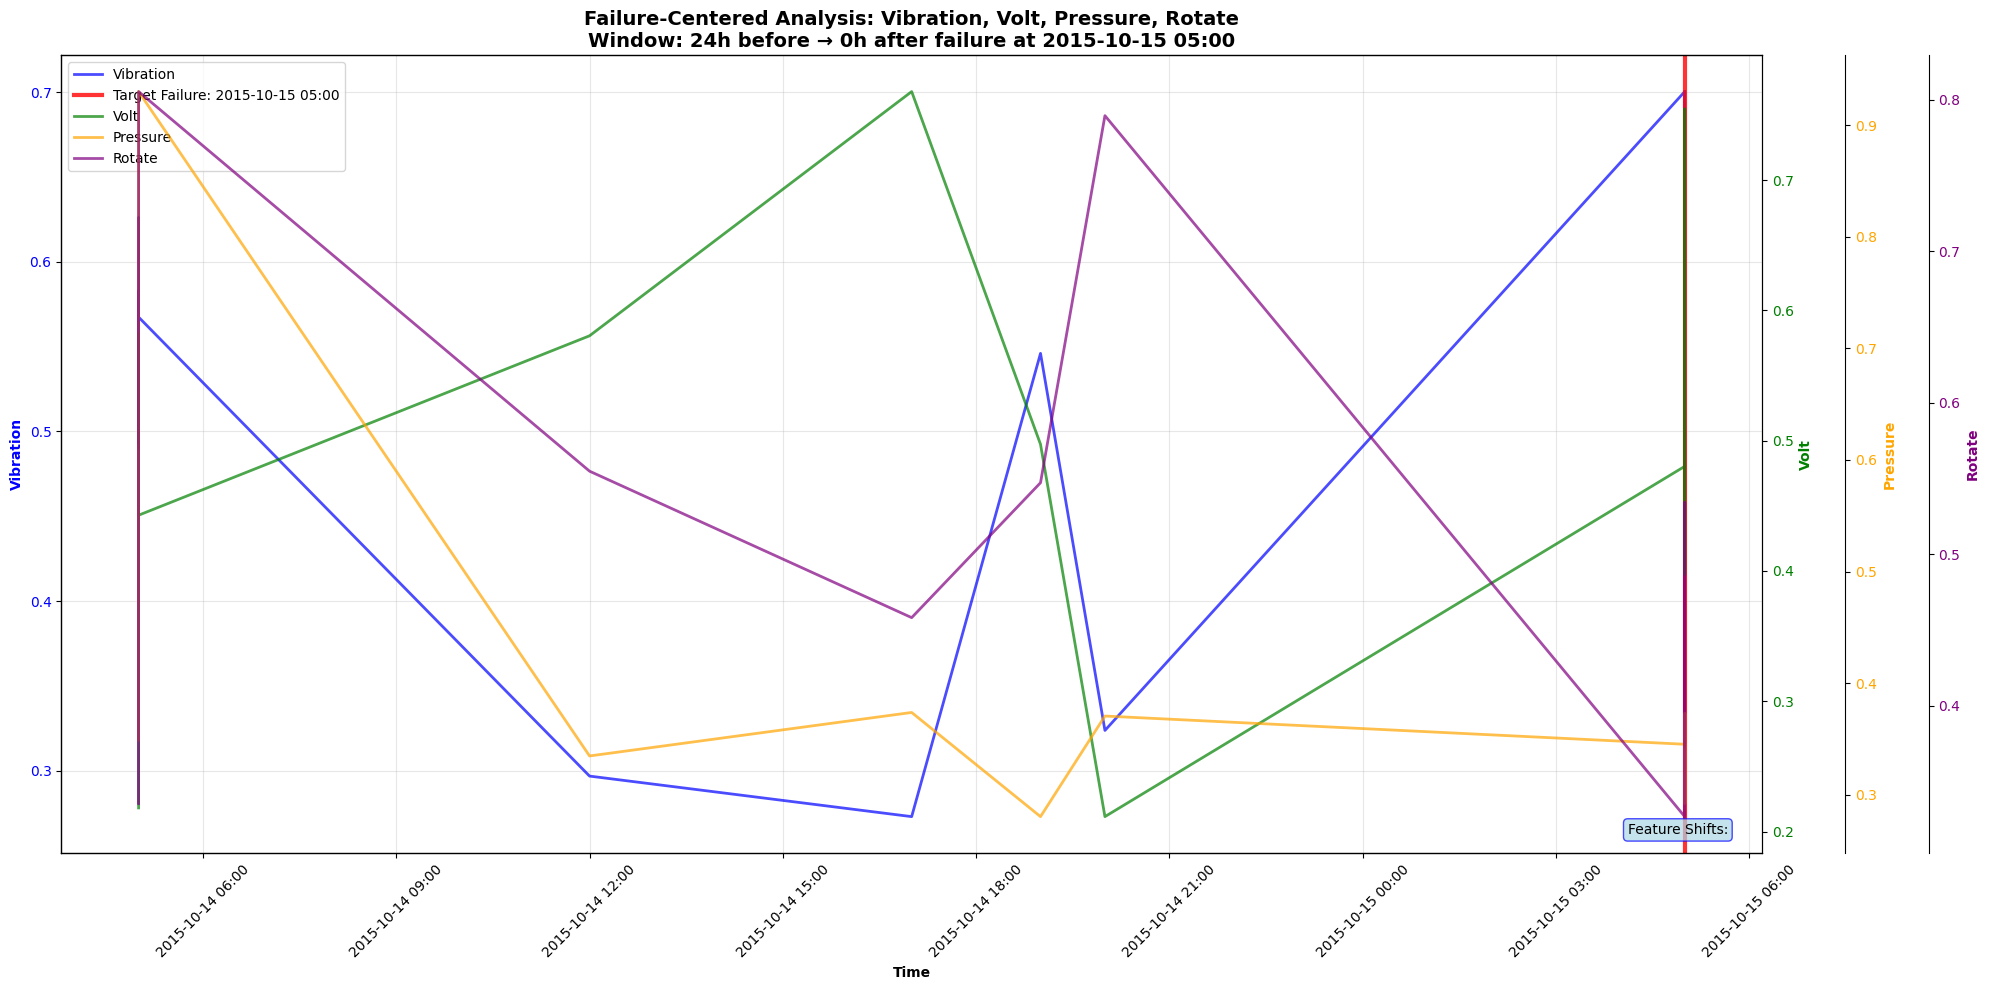


📋 FAILURE WINDOW ANALYSIS:
   🎯 Target failure: 2015-10-15 05:00:00
   📊 Data points in window: 13
   🚨 Total failures in window: 0
   ⏱️  Window duration: 24 hours
   📅 Window range: 2015-10-14 05:00 to 2015-10-15 05:00
   🔄 Applied shifts:
      vibration: +0 hours
      volt: +0 hours
      pressure: +0 hours
      rotate: +0 hours


In [17]:
failure_time = "2015-10-15 05:00:00"
print(f"Analyzing failure at: {failure_time}")

feature_shifts = {
    "vibration": 0,  # Shift vibration
    "volt": 0,  # Shift volt
    "pressure": 0,  # Shift pressure
    "rotate": 0,  # Shift rotate
}


# Ensure df has a datetime index before plotting
if not isinstance(df.index, pd.DatetimeIndex):
    if "datetime" in df.columns:
        df_new = df.copy()
        df_new["datetime"] = pd.to_datetime(df["datetime"])
        df_new.set_index("datetime", inplace=True)
    else:
        raise ValueError(
            "DataFrame must have a 'datetime' column for time-based plotting."
        )


fig1 = flexible_multi_column_plot_with_window_feature_move(
    df=df_new,
    target_col="target",
    columns_to_plot=["vibration", "volt", "pressure", "rotate"],
    failure_datetime=failure_time,
    hours_before=24,  # 8 hours before failure
    hours_after=0,  # 8 hours after failure
    figsize=(20, 10),
    legend_location="upper left",
    show_hours=True,  # Show hours in x-axis labels
    shift_features=feature_shifts,  # Apply feature shifting
)

In [18]:
# Display rows when failure happens

failure_rows = df[df["target"] != 0]
print(f"Number of failure events: {len(failure_rows)}")
print("\nFailure events:")
failure_rows

Number of failure events: 1122

Failure events:


,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
1,2015-01-02 02:00:00,17,0.428857,0.170647,0.164214,0.758246,model1,14,0,0,...,0.0,0.0,0.0,4.0,2,4,0,0,20,20
2,2015-01-02 02:00:00,79,0.751701,0.523797,0.368828,0.291526,model3,14,0,0,...,0.0,0.0,0.0,0.0,2,4,0,0,20,20
3,2015-01-02 02:00:00,73,0.422375,0.498530,0.765776,0.373949,model2,20,0,0,...,0.0,4.0,0.0,0.0,2,4,0,0,20,20
4,2015-01-02 02:00:00,83,0.348804,0.448234,0.435553,0.695304,model4,18,0,0,...,0.0,0.0,0.0,2.0,2,4,0,0,20,20
5,2015-01-02 02:00:00,45,0.744968,0.597842,0.291706,1.000000,model3,14,0,0,...,0.0,0.0,0.0,0.0,2,4,0,0,20,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,2015-12-31 05:00:00,95,0.863064,0.542359,0.559759,0.294727,model2,18,0,0,...,0.0,1.0,0.0,0.0,5,3,0,0,359,23
2233,2015-12-31 05:00:00,64,0.620622,0.515321,0.275955,0.411961,model3,20,0,0,...,0.0,1.0,0.0,0.0,5,3,0,0,719,23
2234,2015-12-31 05:00:00,95,0.863064,0.542359,0.559759,0.294727,model2,18,0,0,...,0.0,1.0,0.0,0.0,5,3,0,0,359,23
2235,2015-12-31 05:00:00,64,0.620622,0.515321,0.275955,0.411961,model3,20,0,0,...,0.0,1.0,0.0,0.0,5,3,0,0,719,23


In [19]:
def show_rows_between(df, x, y):
    """
    Display rows in df where 'datetime' is between x and y (inclusive).
    x, y: string or pd.Timestamp
    """
    mask = (df["datetime"] >= pd.to_datetime(x)) & (df["datetime"] <= pd.to_datetime(y))
    return df[mask]


# Example usage:
x = "2015-10-14 05:00:00"
y = "2015-10-15 05:00:00"
show_rows_between(df, x, y)

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
1785,2015-10-14 05:00:00,4,0.218127,0.438418,0.411516,0.490034,model3,7,0,0,...,0.0,3.0,0.0,0.0,5,2,0,0,360,23
1786,2015-10-14 05:00:00,81,0.582450,0.335698,0.349092,0.501931,model4,1,0,0,...,0.0,3.0,0.0,0.0,5,2,0,0,360,23
1787,2015-10-14 05:00:00,24,0.457629,0.673616,0.612778,0.625954,model1,20,0,0,...,0.0,4.0,0.0,0.0,5,2,0,0,359,23
1788,2015-10-14 05:00:00,81,0.582450,0.335698,0.349092,0.501931,model4,1,0,0,...,0.0,3.0,0.0,0.0,5,2,0,0,360,23
1789,2015-10-14 05:00:00,16,0.442757,0.805369,0.929972,0.567407,model1,3,0,0,...,0.0,4.0,0.0,0.0,5,2,0,0,719,23
1790,2015-10-14 12:00:00,64,0.580442,0.554891,0.334782,0.296880,model3,20,0,0,...,0.0,0.0,0.0,0.0,12,2,0,1,654,202
1791,2015-10-14 17:00:00,13,0.767868,0.458251,0.373744,0.272989,model1,15,0,0,...,0.0,0.0,0.0,0.0,17,2,0,1,155,250
1792,2015-10-14 19:00:00,16,0.497170,0.547270,0.280426,0.546037,model1,3,0,0,...,0.0,0.0,0.0,3.0,19,2,0,0,13,37
1793,2015-10-14 20:00:00,35,0.211428,0.789483,0.370544,0.323785,model1,17,0,0,...,0.0,0.0,0.0,0.0,20,2,0,0,278,88
1794,2015-10-15 05:00:00,9,0.480250,0.326948,0.345257,0.700335,model4,7,0,0,...,0.0,3.0,0.0,0.0,5,3,0,0,360,23



<br> <br> <br>


### Note

It is **normal** and **expected** that you have multiple rows with the same `datetime` but from different machines in your final balanced dataset. Each row represents the state of a specific machine at a specific time. In predictive maintenance, this is standard practice because:

- Each machine operates independently, so the same timestamp can appear for many machines.
- Your features (sensor readings, etc.) and target label are specific to each machine at that time.

**You do not need to remove or modify these rows.**  
Just make sure you have a column (e.g., `machineID` or similar) that identifies which machine each row belongs to. This is important for:
- Grouping by machine for analysis or modeling,
- Avoiding data leakage between machines during train/test splits.

**Summary:**  
- Multiple rows with the same `datetime` but different machines is correct.
- Ensure you have a machine identifier column in your dataset.

If you dropped the machine identifier, you should add it back for clarity and proper modeling.

In [20]:
df.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'model', 'age', 'errorID', 'comp', 'failure', 'target', 'volt_lag_1h',
       'volt_lag_6h', 'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h',
       'volt_std_24h', 'volt_min_24h', 'volt_max_24h', 'volt_mean_6h',
       'volt_std_6h', 'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h',
       'rotate_lag_24h', 'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h',
       'rotate_max_24h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h',
       'pressure_lag_6h', 'pressure_lag_12h', 'pressure_lag_24h',
       'pressure_mean_24h', 'pressure_std_24h', 'pressure_min_24h',
       'pressure_max_24h', 'pressure_mean_6h', 'pressure_std_6h',
       'vibration_lag_1h', 'vibration_lag_6h', 'vibration_lag_12h',
       'vibration_lag_24h', 'vibration_mean_24h', 'vibration_std_24h',
       'vibration_min_24h', 'vibration_max_24h', 'vibration_mean_6h',
       'vibration_std_6h', 'errorID_lag_1h', 'errorID_lag_6h',


In [21]:
df_backup = df.copy()

In [ ]:
df.drop(
    columns=[
        # 'comp_lag_1h',
        #  'comp_lag_6h',
        #  'comp_lag_12h',
        #  'maint_count_6h',
        #  'maint_count_24h',
        "machineID",
        "model",
        "hour",
        "day_of_week",
        "is_weekend",
        "is_working_hours",
        #  'hours_since_maint',
        #  'hours_since_error',
        #  'comp'
    ],
    inplace=True,
)
# df.columns

<br> <br> <br>


## walk_forward_validation():

- **Time Series Integrity:** It respects the temporal order of your data, always training on the past and testing on the future, which prevents data leakage.
- **Realistic Evaluation:** This method simulates real-world deployment, where you only have access to historical data when making predictions.
- **Robustness:** It provides a more reliable estimate of model performance on unseen, future data compared to random cross-validation.
- **Handles Non-Stationarity:** If your data distribution changes over time (common in predictive maintenance), walk-forward validation helps you detect and adapt to these changes.
- **Best Practice for Predictive Maintenance:** For time-dependent problems like yours, walk-forward validation is the industry standard for model selection and evaluation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def walk_forward_validation(df, n_splits=5, path_file="./models/"):
    """
    Walk-forward validation for binary and multiclass classification.
    Computes ROC AUC, Normalized AUC, Youden Index (binary only), Precision, Recall, F1, Accuracy.
    Saves best models and visualizes metrics for each model separately.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with features and target
    n_splits : int
        Number of time series splits for validation
    path_file : str
        Directory path to save trained models

    Returns:
    --------
    results : dict
        Dictionary containing all metrics for each model
    best_models : dict
        Dictionary containing the best trained model for each algorithm
    """

    print(f"🚀 Starting Walk-Forward Validation with {n_splits} splits")
    print(f"💾 Models will be saved to: {path_file}")

    # Create directory if it doesn't exist
    os.makedirs(path_file, exist_ok=True)

    # Prepare features and target
    exclude_cols = ["datetime", "machineID", "failure", "binary_failure", "target"]
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    X = df[feature_cols].fillna(0)
    y = df["target"]

    print(f"📊 Dataset shape: {X.shape}")
    print(f"🎯 Target distribution: {y.value_counts().to_dict()}")

    # Map target to consecutive integers for compatibility
    unique_classes = sorted(y.unique())
    class_mapping = {v: i for i, v in enumerate(unique_classes)}
    y_mapped = y.map(class_mapping)
    n_classes = len(unique_classes)
    is_binary = n_classes == 2

    print(
        f"📈 Problem type: {'Binary' if is_binary else 'Multiclass'} ({n_classes} classes)"
    )

    # Define models
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=100,
            max_depth=6,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
            force_col_wise=True,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=100,
            max_depth=6,
            random_state=42,
            eval_metric="logloss" if is_binary else "mlogloss",
            verbosity=0,
            use_label_encoder=False,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_state=42,
            verbose=False,
            allow_writing_files=False,
        ),
    }

    # Initialize results storage
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = {}
    best_models = {}

    for model_name in models.keys():
        results[model_name] = {
            "auc": [],
            "norm_auc": [],
            "youden": [],
            "precision": [],
            "recall": [],
            "f1": [],
            "accuracy": [],
            "fold_models": [],  # Store model from each fold
        }

    print(f"\n🔄 Starting {n_splits}-fold time series validation...")

    # Perform walk-forward validation
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        print(f"\n📅 Fold {fold}/{n_splits}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_mapped.iloc[train_idx], y_mapped.iloc[test_idx]

        print(f"   Train: {len(X_train)} samples, Test: {len(X_test)} samples")

        for model_name, model in models.items():
            try:
                print(f"   🤖 Training {model_name}...")

                # Train model
                model_copy = type(model)(**model.get_params())  # Create fresh copy
                model_copy.fit(X_train, y_train)

                # Make predictions
                y_pred = model_copy.predict(X_test)
                y_proba = model_copy.predict_proba(X_test)

                # Calculate metrics
                if is_binary:
                    y_proba_pos = y_proba[:, 1]
                    auc = roc_auc_score(y_test, y_proba_pos)
                    norm_auc = (auc - 0.5) / 0.5  # Normalized AUC
                    fpr, tpr, thresholds = roc_curve(y_test, y_proba_pos)
                    youden = max(tpr - fpr)  # Youden Index
                else:
                    auc = roc_auc_score(
                        y_test, y_proba, multi_class="ovr", average="macro"
                    )
                    norm_auc = np.nan  # Not applicable for multiclass
                    youden = np.nan  # Not applicable for multiclass

                precision = precision_score(
                    y_test, y_pred, average="macro", zero_division=0
                )
                recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
                f1score = f1_score(y_test, y_pred, average="macro", zero_division=0)
                acc = accuracy_score(y_test, y_pred)

                # Store results
                results[model_name]["auc"].append(auc)
                results[model_name]["norm_auc"].append(norm_auc)
                results[model_name]["youden"].append(youden)
                results[model_name]["precision"].append(precision)
                results[model_name]["recall"].append(recall)
                results[model_name]["f1"].append(f1score)
                results[model_name]["accuracy"].append(acc)
                results[model_name]["fold_models"].append(model_copy)

                print(f"      ✅ AUC: {auc:.4f}, F1: {f1score:.4f}, Acc: {acc:.4f}")

            except Exception as e:
                print(f"      ❌ {model_name} failed on fold {fold}: {e}")
                # Fill with NaN for failed folds
                for metric in [
                    "auc",
                    "norm_auc",
                    "youden",
                    "precision",
                    "recall",
                    "f1",
                    "accuracy",
                ]:
                    results[model_name][metric].append(np.nan)
                results[model_name]["fold_models"].append(None)

    print(f"\n🎯 Validation completed! Selecting best models and saving...")

    # Select best model for each algorithm (based on mean F1 score)
    for model_name, model_results in results.items():
        f1_scores = [score for score in model_results["f1"] if not np.isnan(score)]
        if f1_scores:
            best_fold_idx = np.nanargmax(model_results["f1"])
            best_models[model_name] = model_results["fold_models"][best_fold_idx]

            # Save best model
            if best_models[model_name] is not None:
                model_path = os.path.join(path_file, f"{model_name}_best_model.pkl")
                with open(model_path, "wb") as f:
                    pickle.dump(best_models[model_name], f)
                print(f"💾 Saved {model_name} to {model_path}")
        else:
            best_models[model_name] = None
            print(f"⚠️  No valid model for {model_name}")

    # Create visualizations - separate plot for each model
    print(f"\n📊 Creating visualizations...")

    metrics_to_plot = ["auc", "precision", "recall", "f1", "accuracy"]
    if is_binary:
        metrics_to_plot.extend(["norm_auc", "youden"])

    metric_names = {
        "auc": "ROC AUC",
        "norm_auc": "Normalized AUC",
        "youden": "Youden Index",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1 Score",
        "accuracy": "Accuracy",
    }

    colors = [
        "#2E8B57",
        "#FF6B6B",
        "#4ECDC4",
        "#45B7D1",
        "#96CEB4",
        "#FFEAA7",
        "#DDA0DD",
    ]

    # Create individual plots for each model
    n_models = len(
        [
            name
            for name in models.keys()
            if any(not np.isnan(val) for val in results[name]["f1"])
        ]
    )
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    model_idx = 0
    for model_name, model_results in results.items():
        # Skip if all results are NaN
        if all(np.isnan(val) for val in model_results["f1"]):
            continue

        ax = axes[model_idx]

        for i, metric in enumerate(metrics_to_plot):
            metric_values = model_results[metric]
            if not all(np.isnan(metric_values)):
                ax.plot(
                    range(1, n_splits + 1),
                    metric_values,
                    marker="o",
                    linewidth=2,
                    markersize=6,
                    color=colors[i % len(colors)],
                    label=metric_names[metric],
                    alpha=0.8,
                )

        ax.set_xlabel("Fold", fontweight="bold")
        ax.set_ylabel("Score", fontweight="bold")
        ax.set_title(
            f"{model_name} - Walk Forward Validation", fontweight="bold", fontsize=14
        )
        ax.legend(loc="best", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.1)

        # Add mean performance text
        mean_f1 = np.nanmean(model_results["f1"])
        mean_auc = np.nanmean(model_results["auc"])
        ax.text(
            0.02,
            0.98,
            f"Mean F1: {mean_f1:.3f}\nMean AUC: {mean_auc:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7),
        )

        model_idx += 1

    # Hide unused subplots
    for i in range(model_idx, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(path_file, "walk_forward_validation_results.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Print summary statistics
    print(f"\n📈 VALIDATION SUMMARY:")
    print("=" * 60)

    for model_name, model_results in results.items():
        if not all(np.isnan(val) for val in model_results["f1"]):
            mean_scores = {}
            std_scores = {}
            for metric in ["auc", "precision", "recall", "f1", "accuracy"]:
                values = [v for v in model_results[metric] if not np.isnan(v)]
                if values:
                    mean_scores[metric] = np.mean(values)
                    std_scores[metric] = np.std(values)
                else:
                    mean_scores[metric] = np.nan
                    std_scores[metric] = np.nan

            print(f"\n🤖 {model_name}:")
            print(f"   AUC:       {mean_scores['auc']:.4f} ± {std_scores['auc']:.4f}")
            print(
                f"   Precision: {mean_scores['precision']:.4f} ± {std_scores['precision']:.4f}"
            )
            print(
                f"   Recall:    {mean_scores['recall']:.4f} ± {std_scores['recall']:.4f}"
            )
            print(f"   F1 Score:  {mean_scores['f1']:.4f} ± {std_scores['f1']:.4f}")
            print(
                f"   Accuracy:  {mean_scores['accuracy']:.4f} ± {std_scores['accuracy']:.4f}"
            )

    # Save results to file
    results_summary = {}
    for model_name, model_results in results.items():
        results_summary[model_name] = {
            metric: {
                "mean": np.nanmean(values),
                "std": np.nanstd(values),
                "values": values,
            }
            for metric, values in model_results.items()
            if metric != "fold_models"
        }

    results_path = os.path.join(path_file, "validation_results.pkl")
    with open(results_path, "wb") as f:
        pickle.dump(results_summary, f)
    print(f"\n💾 Results saved to {results_path}")

    print(f"\n🎉 Walk-forward validation completed successfully!")

    return results, best_models, X_train, y_train, X_test, y_test


# Example usage:
# results, best_models = walk_forward_validation(df, n_splits=5, path_file="./trained_models/")



This comprehensive implementation:

**Features:**
1. **Saves Models**: Saves the best performing model for each algorithm based on F1 score
2. **Individual Visualizations**: Creates separate plots for each model showing all metrics
3. **Comprehensive Metrics**: Calculates AUC, Normalized AUC, Youden Index (binary), Precision, Recall, F1, Accuracy
4. **Error Handling**: Gracefully handles model training failures
5. **Results Export**: Saves detailed results to pickle files
6. **Summary Statistics**: Provides mean ± std for all metrics

**Key Improvements:**
- **Model Persistence**: Each best model is saved as a `.pkl` file
- **Visual Clarity**: Separate subplot for each model with color-coded metrics
- **Detailed Logging**: Progress tracking and performance summaries
- **Flexible Path**: Customizable save directory
- **Result Storage**: Both models and metrics are saved for later analysis

**Usage:**


🚀 Starting Walk-Forward Validation with 5 splits
💾 Models will be saved to: models/azure_pm
📊 Dataset shape: (2244, 59)
🎯 Target distribution: {0: 1122, 2: 404, 1: 330, 4: 207, 3: 181}
📈 Problem type: Multiclass (5 classes)

🔄 Starting 5-fold time series validation...

📅 Fold 1/5
   Train: 374 samples, Test: 374 samples
   🤖 Training RandomForest...
      ✅ AUC: 0.9951, F1: 0.9506, Acc: 0.9545
   🤖 Training LightGBM...
      ✅ AUC: 0.9975, F1: 0.9690, Acc: 0.9733
   🤖 Training XGBoost...
      ✅ AUC: 0.9990, F1: 0.9753, Acc: 0.9813
   🤖 Training CatBoost...
      ✅ AUC: 0.9984, F1: 0.9645, Acc: 0.9652

📅 Fold 2/5
   Train: 748 samples, Test: 374 samples
   🤖 Training RandomForest...
      ✅ AUC: 0.9952, F1: 0.9101, Acc: 0.9332
   🤖 Training LightGBM...
      ✅ AUC: 0.9972, F1: 0.9332, Acc: 0.9519
   🤖 Training XGBoost...
      ✅ AUC: 0.9967, F1: 0.9379, Acc: 0.9572
   🤖 Training CatBoost...
      ✅ AUC: 0.9977, F1: 0.9247, Acc: 0.9492

📅 Fold 3/5
   Train: 1122 samples, Test: 374 sampl

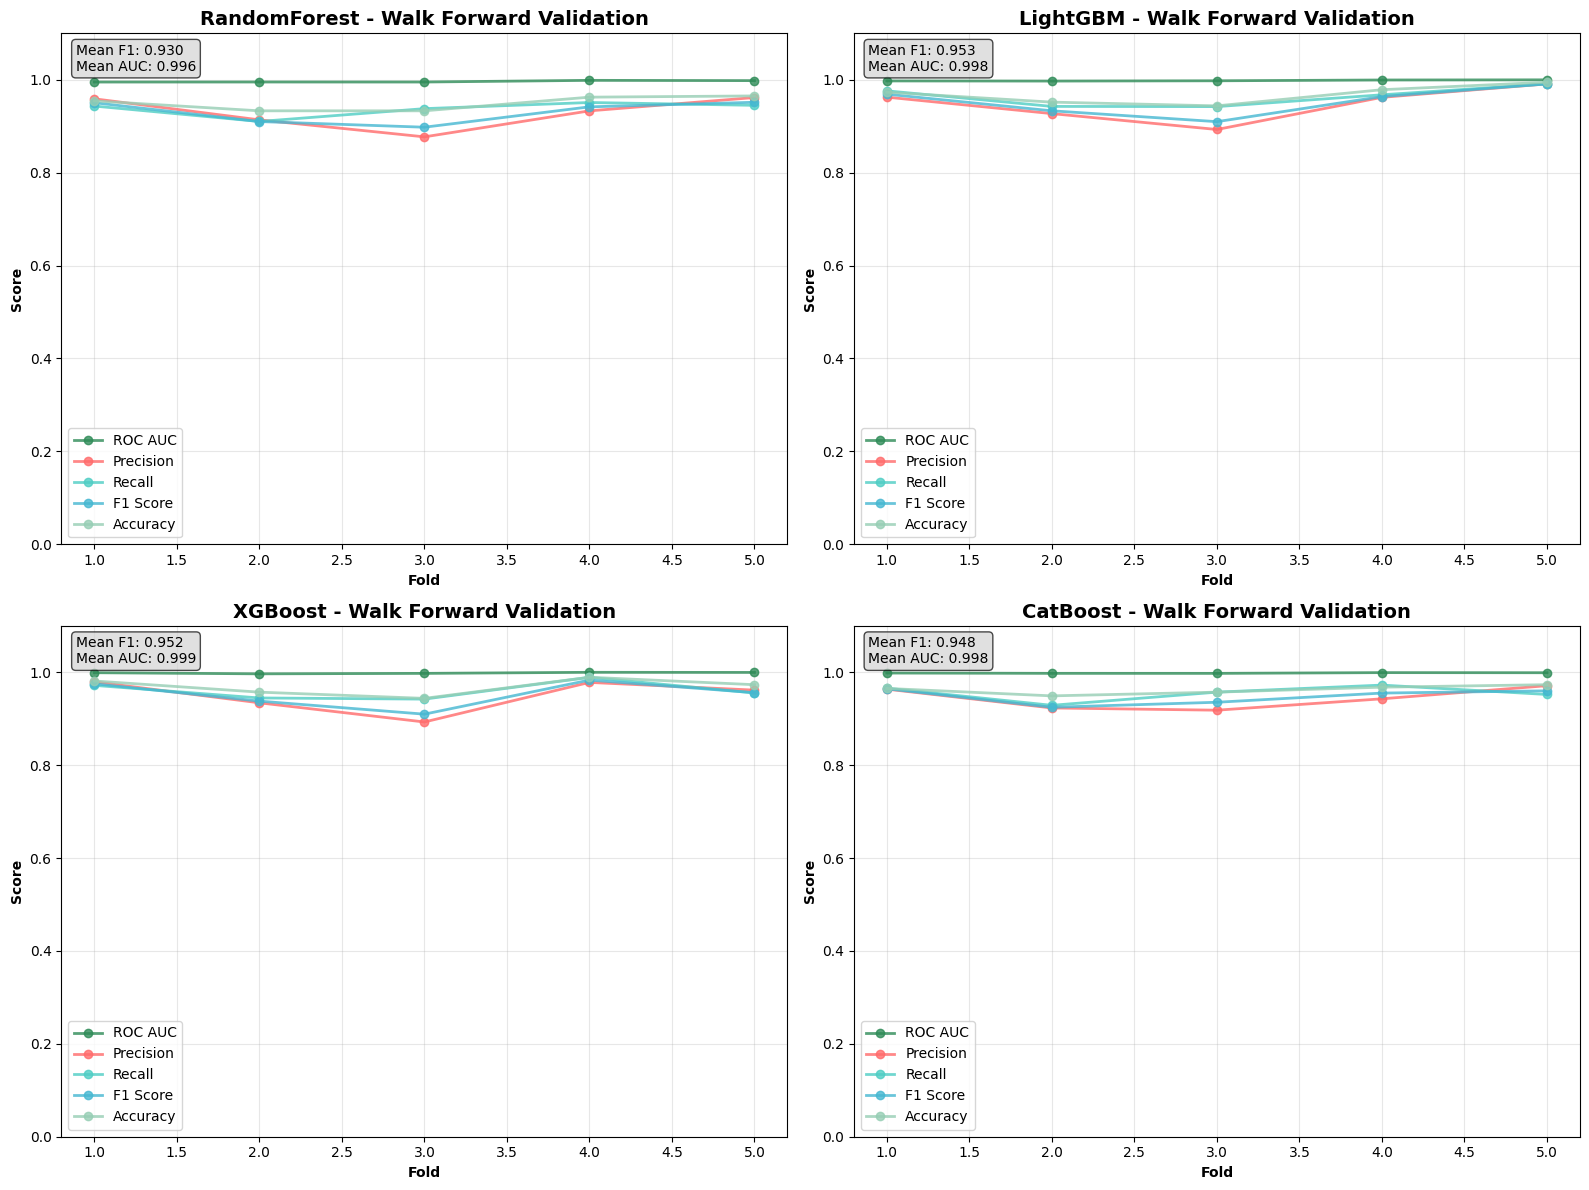


📈 VALIDATION SUMMARY:

🤖 RandomForest:
   AUC:       0.9965 ± 0.0016
   Precision: 0.9289 ± 0.0314
   Recall:    0.9375 ± 0.0143
   F1 Score:  0.9304 ± 0.0222
   Accuracy:  0.9497 ± 0.0140

🤖 LightGBM:
   AUC:       0.9984 ± 0.0011
   Precision: 0.9472 ± 0.0339
   Recall:    0.9640 ± 0.0191
   F1 Score:  0.9534 ± 0.0286
   Accuracy:  0.9684 ± 0.0184

🤖 XGBoost:
   AUC:       0.9986 ± 0.0012
   Precision: 0.9493 ± 0.0325
   Recall:    0.9606 ± 0.0176
   F1 Score:  0.9525 ± 0.0265
   Accuracy:  0.9690 ± 0.0164

🤖 CatBoost:
   AUC:       0.9984 ± 0.0007
   Precision: 0.9438 ± 0.0210
   Recall:    0.9553 ± 0.0149
   F1 Score:  0.9480 ± 0.0153
   Accuracy:  0.9626 ± 0.0085

💾 Results saved to models/azure_pm\validation_results.pkl

🎉 Walk-forward validation completed successfully!


In [ ]:
results, best_models, X_train, y_train, X_test, y_test = walk_forward_validation(
    df, n_splits=5, path_file="models/azure_pm"
)

In [25]:
best_models["RandomForest"]

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

<br> <br>

---

<br> <br> <br>


# Causality

In [ ]:
def create_causal_network(df, features, regularize=True, noise_level=1e-4):
    X_selected = df[features].values

    # Initialize the VARLiNGAM model
    model = lingam.VARLiNGAM()

    # Attempt to fit the model; add noise if a LinAlgError occurs
    try:
        model.fit(X_selected)
    except np.linalg.LinAlgError as e:
        print("LinAlgError encountered during model fitting:", e)
        if regularize:
            print(
                f"Applying regularization: adding noise (std={noise_level}) to the data and trying again."
            )
            X_selected += np.random.normal(0, noise_level, X_selected.shape)
            model.fit(X_selected)
        else:
            raise e

    # Retrieve the adjacency matrices (one per lag)
    adjacency_matrices = model.adjacency_matrices_

    # Build a directed graph and create a list of dictionaries for each non-zero edge.
    G = nx.DiGraph()
    G.add_nodes_from(features)
    n_features = len(features)
    structured_adjacency = []

    # Loop through each adjacency matrix (one per lag)
    for lag_index, adj_matrix in enumerate(adjacency_matrices):
        for i in range(n_features):
            for j in range(n_features):
                weight = adj_matrix[i, j]
                if weight != 0:
                    edge_dict = {
                        "source_feature": features[i],
                        "target_feature": features[j],
                        "effect_strength": weight,
                    }
                    structured_adjacency.append(edge_dict)
                    G.add_edge(features[i], features[j], weight=weight)

    # Plot the graph using a spring layout for clarity
    pos = nx.spring_layout(G, seed=42)  # seed for reproducibility
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=1500,
        arrowstyle="->",
        arrowsize=20,
        edge_color="gray",
        font_size=10,
        ax=ax,
    )

    # Display the edge weights formatted to two decimal places
    edge_labels = nx.get_edge_attributes(G, "weight")
    edge_labels = {edge: f"{weight:.2f}" for edge, weight in edge_labels.items()}
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_color="red", ax=ax
    )

    ax.set_title("Causal Network Graph from VARLiNGAM")
    ax.axis("off")
    # plt.show()
    plt.close()

    return structured_adjacency, fig

In [ ]:
cols_without_datetime_failure = [
    col for col in df.columns if "datetime" not in col and "failure" not in col
]


structured_adjacency, fig = create_causal_network(
    df=df, features=cols_without_datetime_failure
)

---

<br> <br> 

# Generate top-n rows using SHAP

#### Read ML models

In [ ]:
model_dir = f"models/azure_pm/"
pkl_files = glob.glob(os.path.join(model_dir, "*.pkl"))

models = {}
for file_path in pkl_files:
    model_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, "rb") as f:
        models[model_name] = pickle.load(f)

print(f"Loaded {len(models)} models: {list(models.keys())}")

my_models = {
    "catboost_model": "CatBoost_best_model",
    "lightgbm_model": "LightGBM_best_model",
    "randomforest_model": "RandomForest_best_model",
    "xgboost_model": "XGBoost_best_model",
}

# model = models["XGBoost"]
# model = models[my_models["catboost_model"]]
# model = models[my_models["lightgbm_model"]]
# model = models[my_models["randomforest_model"]]
model = models[my_models["xgboost_model"]]
model

Loaded 5 models: ['CatBoost_best_model', 'LightGBM_best_model', 'RandomForest_best_model', 'validation_results', 'XGBoost_best_model']


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

<br> <br> <br>

## Find Uncertain Rows

In [ ]:
def get_uncertain_rows(X_test, y_test, model, uncertainty_threshold=0.5):
    """
    Returns rows from X_test where the model's prediction confidence is below the uncertainty_threshold
    and the true target is not 0. Also prints the predicted class, its probability, and the true target value for each uncertain row.

    Parameters:
        X_test (pd.DataFrame): Test features.
        y_test (array-like): True labels for X_test.
        model: Trained ML model with predict_proba method.
        uncertainty_threshold (float): Maximum probability threshold for uncertainty.

    Returns:
        pd.DataFrame: Uncertain rows from X_test with their true and predicted labels and probabilities.
    """
    probs = model.predict_proba(X_test)
    max_probs = probs.max(axis=1)
    preds = model.classes_[probs.argmax(axis=1)]
    mask = (max_probs < uncertainty_threshold) & (y_test != 0)

    uncertain_rows = X_test[mask].copy()
    uncertain_rows["true_label"] = y_test[mask]
    uncertain_rows["predicted_label"] = preds[mask]
    uncertain_rows["max_probability"] = max_probs[mask]
    uncertain_rows["all_probabilities"] = list(probs[mask])

    # Print predicted class, probability, and true target value for each uncertain row
    for idx, row in uncertain_rows.iterrows():
        print(
            f"Index: {idx}, Predicted class: {row['predicted_label']}, "
            f"Probability: {row['max_probability']:.4f}, True target value: {row['true_label']}"
        )

    return uncertain_rows


# Example usage:
uncertain_rows = get_uncertain_rows(
    X_test=X_test, y_test=y_test, model=model, uncertainty_threshold=0.6
)
display(uncertain_rows)

Index: 2025, Predicted class: 2, Probability: 0.3629, True target value: 2
Index: 2052, Predicted class: 3, Probability: 0.5105, True target value: 2
Index: 2131, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2133, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2135, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2136, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2193, Predicted class: 2, Probability: 0.5444, True target value: 2


,volt,rotate,pressure,vibration,age,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hours_since_maint,hours_since_error,true_label,predicted_label,max_probability,all_probabilities
2025,0.675499,0.443956,0.484717,0.490687,10,0,0,0.488869,0.298902,0.452795,...,0.0,3.0,0.0,0.0,360,23,2,2,0.362912,"[0.18536901, 0.17171231, 0.36291197, 0.1391076..."
2052,0.336190,0.503227,0.659134,0.528144,3,0,0,0.485505,0.636523,0.317159,...,0.0,2.0,0.0,0.0,360,23,2,3,0.510512,"[0.021592187, 0.008716429, 0.4437634, 0.510512..."
2131,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2133,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2135,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2136,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2193,0.607624,0.260010,0.403750,0.415891,20,0,0,0.643974,0.787790,0.714991,...,0.0,7.0,0.0,0.0,360,18,2,2,0.544413,"[0.0056506493, 0.44892198, 0.5444131, 0.000334..."


In [30]:
# df["comp"].value_counts()

In [ ]:
row_number = 2131


random_row = X_test.loc[row_number].to_frame().T
random_row_target_label = uncertain_rows.loc[row_number]["true_label"]
print(
    f"The true label is: {uncertain_rows.loc[row_number]['true_label']}, and the model predicted {uncertain_rows.loc[row_number]['predicted_label']}"
)

display(random_row)

# random_row.drop(columns=["comp_lag_12h"], inplace=True)

The true label is: 1, and the model predicted 1


,volt,rotate,pressure,vibration,age,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,...,errorID_lag_12h,comp_lag_1h,comp_lag_6h,comp_lag_12h,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hours_since_maint,hours_since_error
2131,0.93799,0.430177,0.395643,0.585208,15.0,0.0,0.0,0.691865,0.570378,0.59769,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1080.0,23.0


<br> <br> 

## Generate top-n rows using SHAP

In [ ]:
def get_top_n_shap_features(random_row, model, top_n=10):
    feature_names = model.feature_names_in_
    X_row = random_row
    X_row = X_row.apply(pd.to_numeric, errors="coerce")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = (
        pd.DataFrame(
            {
                "feature_name": feature_names[:min_len],
                "feature_importance": shap_abs[:min_len],
            }
        )
        .sort_values("feature_importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return df_shap

In [34]:
# random_row.columns

In [ ]:
def visualize_top_features_shap(random_row, model, top_n=10):
    df_shap = get_top_n_shap_features(random_row=random_row, model=model, top_n=top_n)
    display(df_shap)

    # Visualize SHAP values from df_shap as a horizontal bar plot
    plt.figure(figsize=(8, 6))
    plt.barh(
        df_shap["feature_name"][::-1],
        df_shap["feature_importance"][::-1],
        color="skyblue",
    )
    plt.xlabel("SHAP Value (absolute)")
    plt.title("Top SHAP Feature Importances")
    plt.show()
    return df_shap

,feature_name,feature_importance
0,maint_count_24h,3.221957
1,hours_since_maint,0.315019
2,vibration_mean_6h,0.193681
3,pressure,0.161268
4,volt_std_6h,0.152492
5,rotate,0.136732
6,hours_since_error,0.126361
7,comp_lag_1h,0.123946
8,comp_lag_12h,0.119486
9,errorID,0.104474


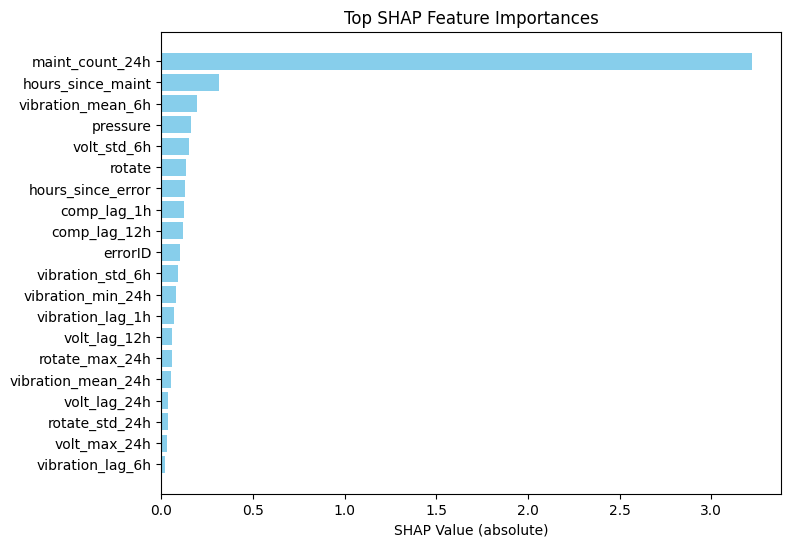

In [36]:
df_shap = visualize_top_features_shap(random_row=random_row, model=model, top_n=20)

<br> <br>

---

<br> <br> <br>

# Taxonomy  

In [ ]:
def format_taxonomy(taxonomy_json):
    """Formats a hierarchical taxonomy into a tree-like string."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON string if needed

    # Build tree structure
    tree = defaultdict(list)
    for feature, (_, parent) in taxonomy_json.items():
        tree[parent].append(feature)

    def display_tree(parent="Root", level=0):
        """Recursively formats the tree structure with icons and connectors."""
        if parent not in tree:
            return ""

        result = ""
        for idx, child in enumerate(tree[parent]):
            is_parent = child in tree  # Check if child has further children
            icon = (
                "📂" if is_parent else "📄"
            )  # Folder for parents, file for leaf nodes
            connector = (
                "└── " if idx == len(tree[parent]) - 1 else "├── "
            )  # Tree connectors
            result += "  " * level + connector + f"{icon} {child}\n"
            result += display_tree(child, level + 1)  # Recursive call for children

        return result

    return f"\n📌 **Taxonomy Structure:**\n\n{display_tree('Root')}".strip()


def get_taxonomy_paths(taxonomy_json, node_names):
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order

    return {node: get_path(node) for node in node_names}


with open("../../taxonomy/deepseek.json", "r") as file:
    deepseek_taxonomy = json.load(file)

with open("../../taxonomy/gemma2.json", "r") as file:
    gemma2_taxonomy = json.load(file)

with open("../../taxonomy/llama3.json", "r") as file:
    llama3_taxonomy = json.load(file)

with open("../../taxonomy/gpt4o.json", "r") as file:
    gpt4o_taxonomy = json.load(file)

with open("../../taxonomy/gpt4o_edited.json", "r") as file:
    gpt4o_edited_taxonomy = json.load(file)

In [38]:
print(format_taxonomy(gpt4o_edited_taxonomy))

📌 **Taxonomy Structure:**

├── 📂 datetime
  ├── 📄 hour
  ├── 📄 day_of_week
  ├── 📄 is_weekend
  └── 📄 is_working_hours
├── 📂 volt
  ├── 📄 volt_lag_1h
  ├── 📄 volt_lag_6h
  ├── 📄 volt_lag_12h
  ├── 📄 volt_lag_24h
  ├── 📄 volt_mean_24h
  ├── 📄 volt_std_24h
  ├── 📄 volt_min_24h
  ├── 📄 volt_max_24h
  ├── 📄 volt_mean_6h
  └── 📄 volt_std_6h
├── 📂 rotate
  ├── 📄 rotate_lag_1h
  ├── 📄 rotate_lag_6h
  ├── 📄 rotate_lag_12h
  ├── 📄 rotate_lag_24h
  ├── 📄 rotate_mean_24h
  ├── 📄 rotate_std_24h
  ├── 📄 rotate_min_24h
  ├── 📄 rotate_max_24h
  ├── 📄 rotate_mean_6h
  └── 📄 rotate_std_6h
├── 📂 pressure
  ├── 📄 pressure_lag_1h
  ├── 📄 pressure_lag_6h
  ├── 📄 pressure_lag_12h
  ├── 📄 pressure_lag_24h
  ├── 📄 pressure_mean_24h
  ├── 📄 pressure_std_24h
  ├── 📄 pressure_min_24h
  ├── 📄 pressure_max_24h
  ├── 📄 pressure_mean_6h
  └── 📄 pressure_std_6h
├── 📂 vibration
  ├── 📄 vibration_lag_1h
  ├── 📄 vibration_lag_6h
  ├── 📄 vibration_lag_12h
  ├── 📄 vibration_lag_24h
  ├── 📄 vibration_mean_24h
  ├── 📄 vibra

<br> <br>

#### See the hierarchy

In [ ]:
# Test the function with the openai_taxonomy data

shap_features = {"feature": df_shap["feature_name"].to_list()}
features_to_find = shap_features["feature"]

taxonomy_model = [
    gpt4o_taxonomy,
    llama3_taxonomy,
    gemma2_taxonomy,
    deepseek_taxonomy,
    gpt4o_edited_taxonomy,
]
index = 4

match index:
    case 0:
        print("GPT-4o")
    case 1:
        print("Llama 3.3")
    case 2:
        print("Gemma2")
    case 3:
        print("DeepSeek")
    case 4:
        print("GPT-4o Edited")
    case _:
        print("Unknown model")

try:
    # Get paths for all selected features
    feature_paths = get_taxonomy_paths(taxonomy_model[index], features_to_find)

    # Print the results in a formatted way, removing "Sensor_Reading --> " from the start
    print("\n=== Taxonomy Paths ===\n")
    for feature, path in feature_paths.items():
        if path.startswith("Sensor_Readings --> "):
            path = path[len("Sensor_Readings --> ") :]
        print(f"{path}")
except IndexError as e:
    print("Taxonomy model index is out of reach")

GPT-4o Edited

=== Taxonomy Paths ===

comp --> maint_count_24h
comp --> hours_since_maint
vibration --> vibration_mean_6h
pressure
volt --> volt_std_6h
rotate
errorID --> hours_since_error
comp --> comp_lag_1h
comp --> comp_lag_12h
errorID
vibration --> vibration_std_6h
vibration --> vibration_min_24h
vibration --> vibration_lag_1h
volt --> volt_lag_12h
rotate --> rotate_max_24h
vibration --> vibration_mean_24h
volt --> volt_lag_24h
rotate --> rotate_std_24h
volt --> volt_max_24h
vibration --> vibration_lag_6h


<br> <br> <br>

---

<br> <br> <br>


## Return the sub causal graph

Extracts a sub causal graph from `structured_adjacency` based on the features in `df_shap["feature_name"]` with an option to limit the number of children

In [ ]:
def extract_shap_causal_subgraph(
    df_shap, structured_adjacency, max_children=None, include_target=True
):
    """
    Extract a sub causal graph from structured_adjacency based on SHAP features.

    Args:
        df_shap (pd.DataFrame): DataFrame with 'feature_name' column containing SHAP features
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 'effect_strength'
        max_children (int, optional): Maximum number of children/related features to include per SHAP feature
        include_target (bool): Whether to include edges connected to 'target' variable

    Returns:
        dict: Contains filtered adjacency list and summary statistics
    """
    import pandas as pd

    # Get SHAP features
    shap_features = set(df_shap["feature_name"].tolist())

    # Find all edges where SHAP features are involved
    relevant_edges = []
    feature_connections = {}  # Track connections for each SHAP feature

    for edge in structured_adjacency:
        source = edge["source_feature"]
        target = edge["target_feature"]

        # Check if either source or target is a SHAP feature
        shap_feature_involved = None
        if source in shap_features:
            shap_feature_involved = source
        elif target in shap_features:
            shap_feature_involved = target
        elif include_target and (source == "target" or target == "target"):
            # Include edges to/from target if any end connects to a SHAP feature
            if source in shap_features or target in shap_features:
                shap_feature_involved = source if source in shap_features else target

        if shap_feature_involved:
            if shap_feature_involved not in feature_connections:
                feature_connections[shap_feature_involved] = []

            feature_connections[shap_feature_involved].append(
                {
                    "edge": edge,
                    "strength": abs(edge.get("effect_strength", 0)),
                    "connected_feature": (
                        target if source == shap_feature_involved else source
                    ),
                }
            )

    # Apply max_children filter if specified
    filtered_edges = []
    summary_stats = {
        "original_edges": len(structured_adjacency),
        "shap_features_found": len(feature_connections),
        "shap_features_total": len(shap_features),
        "edges_per_feature": {},
    }

    for shap_feature, connections in feature_connections.items():
        # Sort connections by strength (descending)
        connections.sort(key=lambda x: x["strength"], reverse=True)

        # Apply limit if specified
        if max_children is not None:
            connections = connections[:max_children]

        # Add edges to filtered list
        for conn in connections:
            filtered_edges.append(conn["edge"])

        summary_stats["edges_per_feature"][shap_feature] = len(connections)

    # Remove duplicates while preserving order
    seen = set()
    unique_filtered_edges = []
    for edge in filtered_edges:
        edge_tuple = (edge["source_feature"], edge["target_feature"])
        if edge_tuple not in seen:
            seen.add(edge_tuple)
            unique_filtered_edges.append(edge)

    summary_stats["filtered_edges"] = len(unique_filtered_edges)

    # Find missing SHAP features (not found in causal graph)
    found_features = set(feature_connections.keys())
    missing_features = shap_features - found_features
    summary_stats["missing_shap_features"] = list(missing_features)

    print(f"📊 Subgraph Extraction Summary:")
    print(f"   • Original causal graph edges: {summary_stats['original_edges']}")
    print(
        f"   • SHAP features found in graph: {summary_stats['shap_features_found']}/{summary_stats['shap_features_total']}"
    )
    print(f"   • Filtered subgraph edges: {summary_stats['filtered_edges']}")
    if max_children:
        print(f"   • Max children per feature: {max_children}")
    if missing_features:
        print(f"   • SHAP features not in causal graph: {list(missing_features)}")

    return {
        "subgraph_adjacency": unique_filtered_edges,
        "summary": summary_stats,
        "feature_connections": feature_connections,
    }


def visualize_shap_subgraph(
    subgraph_result, df_shap, filename="shap_causal_subgraph.html"
):
    """
    Create an interactive visualization of the SHAP-based causal subgraph.

    Args:
        subgraph_result (dict): Result from extract_shap_causal_subgraph
        df_shap (pd.DataFrame): Original SHAP features DataFrame
        filename (str): Output HTML filename

    Returns:
        str: Path to the generated HTML file
    """
    from pyvis.network import Network
    import networkx as nx

    subgraph_adjacency = subgraph_result["subgraph_adjacency"]
    shap_features = set(df_shap["feature_name"].tolist())

    # Create NetworkX graph
    G = nx.DiGraph()

    # Add edges
    for edge in subgraph_adjacency:
        source = edge["source_feature"]
        target = edge["target_feature"]
        strength = edge.get("effect_strength", 0)

        G.add_edge(source, target, weight=strength, label=f"{strength:.3f}")

    if not G.nodes():
        print("Warning: No nodes in subgraph to visualize")
        return None

    # Create pyvis network with unified layout
    net = Network(
        height="800px",
        width="100%",
        directed=True,
        cdn_resources="in_line",
        bgcolor="#ffffff",
        font_color="black",
    )

    # Set physics options for unified layout
    net.set_options(
        """
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": {"centralGravity": 0.3, "springLength": 250, "nodeDistance": 200},
        "solver": "repulsion",
        "stabilization": {"iterations": 100}
      },
      "edges": {"arrows": {"to": {"enabled": true}}},
      "interaction": {"dragNodes": true, "dragView": true, "zoomView": true},
      "layout": {
        "improvedLayout": true,
        "hierarchical": {
          "enabled": false
        }
      }
    }
    """
    )

    # Add nodes with styling
    for node in G.nodes():
        is_shap = node in shap_features
        is_target = node == "target"

        if is_target:
            color = "red"
            size = 30
            label = "TARGET"
        elif is_shap:
            color = "orange"
            size = 25
            label = f"SHAP: {node}"
        else:
            color = "lightblue"
            size = 20
            label = node

        net.add_node(
            node,
            label=label,
            color=color,
            size=size,
            title=f"{'SHAP Feature' if is_shap else 'Related Feature'}: {node}",
        )

    # Add edges
    for source, target in G.edges():
        edge_data = G.edges[source, target]
        strength = edge_data.get("weight", 0)

        color = "darkred" if abs(strength) > 0.5 else "gray"
        width = min(8, max(1, abs(strength) * 10))

        net.add_edge(
            source,
            target,
            label=f"{strength:.3f}",
            color=color,
            width=width,
            title=f"Effect strength: {strength:.4f}",
        )

    # Generate HTML content with custom styling to remove dividers
    try:
        html_content = net.generate_html()

        # Remove any horizontal dividers from the HTML
        html_content = html_content.replace("<hr>", "")
        html_content = html_content.replace("<hr/>", "")
        html_content = html_content.replace("<hr />", "")

        # Add custom CSS to ensure unified layout

        custom_css = """
        <style>
        body { margin: 0; padding: 0; }
        #mynetworkid { 
            width: 100%; 
            height: 800px; 
            border: none !important;
            margin: 0 !important;
            padding: 0 !important;
        }
        .vis-network { 
            border: none !important; 
        }
        hr { display: none !important; }
        </style>
        """

        # Insert custom CSS before </head>
        html_content = html_content.replace("</head>", custom_css + "</head>")

        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"✅ Unified subgraph visualization saved to: {filename}")
        return filename
    except Exception as e:
        print(f"❌ Error saving visualization: {e}")
        return None

In [ ]:
# Example usage with your data:
def demo_shap_subgraph_extraction(
    df_shap, structured_adjacency, max_children, filename
):
    """
    Demonstrate the SHAP subgraph extraction with different parameters.
    """
    print("=" * 60)
    print("SHAP CAUSAL SUBGRAPH EXTRACTION DEMO")
    print("=" * 60)

    # 1. Extract full subgraph (no limit on children)
    print("\n subgraph:")
    subgraph_result = extract_shap_causal_subgraph(
        df_shap=df_shap,
        structured_adjacency=structured_adjacency,
        max_children=max_children,
    )

    # 2. Create visualizations
    print("\n🎨 Creating visualizations...")
    visualize_shap_subgraph(
        subgraph_result=subgraph_result, df_shap=df_shap, filename=filename
    )

    return subgraph_result

In [ ]:
# Run the demo to see all options
subgraph_result = demo_shap_subgraph_extraction(
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    max_children=3,  # None=Full subgraph
    filename="three_child_subgraph.html",
)

SHAP CAUSAL SUBGRAPH EXTRACTION DEMO

 subgraph:
📊 Subgraph Extraction Summary:
   • Original causal graph edges: 247
   • SHAP features found in graph: 20/20
   • Filtered subgraph edges: 53
   • Max children per feature: 3

🎨 Creating visualizations...
✅ Unified subgraph visualization saved to: three_child_subgraph.html


<br> <br> <br>

# Counterfactual

<br>

Generate counterfactual examples by perturbing top SHAP features and analyzing how model predictions change. 




<br> <br> 

In [ ]:
def run_advanced_counterfactuals(
    df_shap,
    structured_adjacency,
    base_row,
    model_dict,
    num_runs=10,
    perturbation_scale=0.1,
    perturbation_method="gaussian",  # 'gaussian', 'uniform', or 'fixed'
    fixed_value=None,  # Used if method is 'fixed'
    random_seed=None,
    verbose=True,
):
    """
    Advanced counterfactual generator for SHAP-causal subgraph with improved error handling.
    Tracks feature changes, supports multiple perturbation methods, and logs model predictions.

    Args:
        df_shap (pd.DataFrame): Top SHAP features DataFrame.
        structured_adjacency (list): Causal graph adjacency list.
        base_row (pd.DataFrame or pd.Series): The base row to perturb.
        model_dict (dict): Model dictionary with 'model' and 'feature_names'.
        num_runs (int): Number of counterfactual runs.
        perturbation_scale (float): Scale of random perturbation for features.
        perturbation_method (str): 'gaussian', 'uniform', or 'fixed'.
        fixed_value (float): Value to set if method is 'fixed'.
        random_seed (int or None): Random seed for reproducibility.
        verbose (bool): If True, print detailed logs.

    Returns:
        consistent_nodes (dict): Nodes with consistent values and their value.
        cf_df (pd.DataFrame): All counterfactual results for inspection.
        logs (list): List of dicts with feature changes and predictions for each run.
    """
    import numpy as np
    import pandas as pd

    try:
        if random_seed is not None:
            np.random.seed(random_seed)

        # Handle both DataFrame and Series input for base_row
        if isinstance(base_row, pd.DataFrame):
            if len(base_row) == 1:
                base_row = base_row.iloc[0]  # Convert single-row DataFrame to Series
            else:
                raise ValueError("base_row DataFrame must contain exactly one row")
        elif not isinstance(base_row, pd.Series):
            raise ValueError("base_row must be a pandas Series or single-row DataFrame")

        # Validate inputs
        if df_shap.empty:
            raise ValueError("df_shap DataFrame is empty")

        if "feature_name" not in df_shap.columns:
            raise ValueError("df_shap must have 'feature_name' column")

        # Get the subgraph nodes (features) from the SHAP-causal mapping
        top_features = set(df_shap["feature_name"])
        subgraph_nodes = set()

        # Build subgraph including causal relationships
        for edge in structured_adjacency:
            if (edge["source_feature"] in top_features) or (
                edge["target_feature"] in top_features
            ):
                subgraph_nodes.add(edge["source_feature"])
                subgraph_nodes.add(edge["target_feature"])

        # Filter to only include nodes that exist in base_row
        subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]

        if not subgraph_nodes:
            if verbose:
                print(
                    "Warning: No subgraph nodes found in base_row. Using top_features only."
                )
            subgraph_nodes = [f for f in top_features if f in base_row.index]

        if not subgraph_nodes:
            raise ValueError(
                "No valid features found in base_row that match SHAP features"
            )

        # Store original values for all features (not just subgraph)
        base_values = base_row.copy()
        model = model_dict["model"]
        feature_names = model_dict["feature_names"]

        # Validate that all required features are present
        missing_features = [f for f in feature_names if f not in base_row.index]
        if missing_features and verbose:
            print(f"Warning: Missing features in base_row: {missing_features}")

        counterfactual_results = []
        logs = []
        successful_runs = 0

        # Get original prediction for comparison
        try:
            original_input = pd.DataFrame(
                [
                    {
                        feat: base_row[feat] if feat in base_row.index else 0.0
                        for feat in feature_names
                    }
                ]
            )
            original_input = original_input.apply(
                pd.to_numeric, errors="coerce"
            ).fillna(0)
            original_prediction = model.predict(original_input)[0]
            original_proba = model.predict_proba(original_input)[0]
            if verbose:
                print(
                    f"Original prediction: {original_prediction} (confidence: {max(original_proba):.4f})"
                )
        except Exception as e:
            if verbose:
                print(f"Warning: Could not get original prediction: {e}")
            original_prediction = None
            original_proba = None

        for i in range(num_runs):
            try:
                # Start with a copy of all original values
                perturbed_full = base_values.copy()
                feature_changes = []

                if verbose and i < 5:  # Only print first 5 runs to avoid spam
                    print(f"\nCounterfactual run {i+1}:")

                # Perturb only top SHAP features that exist in the data
                for feat in top_features:
                    if feat in perturbed_full.index:
                        old_value = perturbed_full[feat]

                        # Choose perturbation method
                        if perturbation_method == "gaussian":
                            # Use feature's own standard deviation or SHAP importance as guide
                            feat_importance = df_shap[df_shap["feature_name"] == feat][
                                "feature_importance"
                            ]
                            if not feat_importance.empty:
                                # Scale perturbation by feature importance
                                importance_weight = feat_importance.iloc[0]
                                std = max(
                                    0.01, abs(old_value) * 0.1
                                )  # 10% of current value as base std
                                noise = np.random.normal(
                                    0, perturbation_scale * std * importance_weight
                                )
                            else:
                                noise = np.random.normal(
                                    0,
                                    perturbation_scale
                                    * max(0.01, abs(old_value) * 0.1),
                                )
                            new_value = old_value + noise

                        elif perturbation_method == "uniform":
                            # Scale uniform perturbation by current value
                            range_scale = max(
                                0.01, abs(old_value) * 0.2
                            )  # 20% of current value as range
                            noise = np.random.uniform(
                                -perturbation_scale * range_scale,
                                perturbation_scale * range_scale,
                            )
                            new_value = old_value + noise

                        elif perturbation_method == "fixed":
                            new_value = (
                                fixed_value if fixed_value is not None else old_value
                            )
                            noise = new_value - old_value

                        else:
                            raise ValueError(
                                f"Unknown perturbation_method: {perturbation_method}"
                            )

                        perturbed_full[feat] = new_value
                        feature_changes.append(
                            {
                                "feature": feat,
                                "old_value": old_value,
                                "new_value": new_value,
                                "perturbation": noise,
                                "perturbation_percent": (
                                    (noise / old_value * 100) if old_value != 0 else 0
                                ),
                            }
                        )

                        if verbose and i < 5:
                            print(
                                f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} "
                                f"(Δ={noise:.6f}, {noise/old_value*100:.2f}%)"
                                if old_value != 0
                                else f"  Changed '{feat}': {old_value:.6f} -> {new_value:.6f} (Δ={noise:.6f})"
                            )

                # Prepare input for model prediction
                model_input = {}
                for feat in feature_names:
                    if feat in perturbed_full.index:
                        model_input[feat] = perturbed_full[feat]
                    else:
                        # Use zero for missing features
                        model_input[feat] = 0.0
                        if verbose and i < 3:  # Only warn for first few runs
                            print(
                                f"  Warning: Missing feature '{feat}', using default value 0.0"
                            )

                X_input = pd.DataFrame([model_input])
                X_input = X_input.apply(pd.to_numeric, errors="coerce").fillna(0)

                # Make prediction
                try:
                    y_pred = model.predict(X_input)[0]
                    y_pred_proba = model.predict_proba(X_input)[0]
                    successful_runs += 1

                    # Check if prediction changed from original
                    prediction_changed = (
                        original_prediction is not None
                        and y_pred != original_prediction
                    )

                except Exception as pred_error:
                    if verbose and i < 3:
                        print(f"  Prediction error in run {i+1}: {pred_error}")
                    y_pred = None
                    y_pred_proba = None
                    prediction_changed = False

                # Store only the perturbed features for analysis
                perturbed_subset = {
                    feat: perturbed_full[feat] for feat in subgraph_nodes
                }
                counterfactual_results.append(perturbed_subset)

                logs.append(
                    {
                        "run": i + 1,
                        "feature_changes": feature_changes,
                        "model_prediction": y_pred,
                        "model_prediction_proba": (
                            y_pred_proba.tolist() if y_pred_proba is not None else None
                        ),
                        "prediction_changed": prediction_changed,
                        "success": y_pred is not None,
                        "num_features_changed": len(feature_changes),
                    }
                )

            except Exception as run_error:
                if verbose:
                    print(f"  Error in run {i+1}: {run_error}")
                logs.append(
                    {
                        "run": i + 1,
                        "feature_changes": [],
                        "model_prediction": None,
                        "model_prediction_proba": None,
                        "prediction_changed": False,
                        "success": False,
                        "error": str(run_error),
                        "num_features_changed": 0,
                    }
                )

        # Create results DataFrame
        if counterfactual_results:
            cf_df = pd.DataFrame(counterfactual_results)
        else:
            cf_df = pd.DataFrame()

        # Find consistent nodes: nodes whose value is (almost) the same across all runs
        consistent_nodes = {}
        if not cf_df.empty:
            for col in cf_df.columns:
                values = cf_df[col].values
                if len(values) > 1 and np.allclose(values, values[0], atol=1e-4):
                    consistent_nodes[col] = values[0]
                elif len(values) == 1:
                    consistent_nodes[col] = values[0]

        if verbose:
            print(
                f"\nCompleted {successful_runs}/{num_runs} successful counterfactual runs."
            )

            # Enhanced summary statistics
            print("\n=== Counterfactual Summary ===")

            # Feature change statistics
            for feat in top_features:
                changes = [
                    chg
                    for log in logs
                    for chg in log.get("feature_changes", [])
                    if chg["feature"] == feat
                ]
                if changes:
                    avg_perturb = np.mean([abs(chg["perturbation"]) for chg in changes])
                    avg_percent = np.mean(
                        [abs(chg["perturbation_percent"]) for chg in changes]
                    )
                    print(
                        f"Feature '{feat}': changed {len(changes)} times, "
                        f"avg |perturbation|={avg_perturb:.4f} ({avg_percent:.2f}%)"
                    )

            # Model predictions summary
            preds = [
                log["model_prediction"]
                for log in logs
                if log["model_prediction"] is not None
            ]
            if preds:
                unique, counts = np.unique(preds, return_counts=True)
                pred_dict = dict(zip(unique, counts))
                print("Model predictions across runs:", pred_dict)

                # Prediction change analysis
                changes = [log["prediction_changed"] for log in logs if log["success"]]
                if changes:
                    change_rate = sum(changes) / len(changes) * 100
                    print(
                        f"Prediction changed in {sum(changes)}/{len(changes)} runs ({change_rate:.1f}%)"
                    )
            else:
                print("No successful model predictions.")

            # Show consistent features
            if consistent_nodes:
                print(f"\nConsistent features across all runs:")
                for node, value in list(consistent_nodes.items()):  # Show All
                    print(f"  {node}: {value:.6f}")

                # for node, value in list(consistent_nodes.items())[:5]:  # Show first 5
                #     print(f"  {node}: {value:.6f}")
                # # if len(consistent_nodes) > 5:
                #     print(f"  ... and {len(consistent_nodes) - 5} more")

        return consistent_nodes, cf_df, logs

    except Exception as e:
        if verbose:
            print(f"Critical error in run_advanced_counterfactuals: {e}")
        return {}, pd.DataFrame(), []


def safe_counterfactual_analysis(
    X_test,
    y_test,
    df_shap,
    structured_adjacency,
    model,
    num_runs=100,
    specific_row_index=None,
    uncertainty_threshold=None,
):
    """
    Enhanced wrapper function to safely run counterfactual analysis with better row selection options.

    Args:
        X_test (pd.DataFrame): Test features
        y_test (array-like): Test labels
        df_shap (pd.DataFrame): SHAP features
        structured_adjacency (list): Causal relationships
        model: Trained model
        num_runs (int): Number of counterfactual runs
        specific_row_index (int): Specific row index to analyze (optional)
        uncertainty_threshold (float): If provided, select uncertain predictions only

    Returns:
        tuple: (consistent_nodes, all_counterfactuals, logs, selected_row, row_info)
    """
    try:
        # Validate inputs
        if len(X_test) == 0:
            raise ValueError("X_test is empty")

        if df_shap.empty or "feature_name" not in df_shap.columns:
            raise ValueError("Invalid df_shap DataFrame")

        # Row selection logic
        row_info = {}

        if specific_row_index is not None:
            # Use specific row if provided
            if specific_row_index not in X_test.index:
                raise ValueError(f"Row index {specific_row_index} not found in X_test")
            random_row = X_test.loc[specific_row_index]
            row_info["selection_method"] = "specific"
            row_info["index"] = specific_row_index

        elif uncertainty_threshold is not None:
            # Select from uncertain predictions
            try:
                probs = model.predict_proba(X_test)
                max_probs = probs.max(axis=1)
                uncertain_mask = max_probs < uncertainty_threshold

                if not uncertain_mask.any():
                    print(
                        f"No uncertain predictions found with threshold {uncertainty_threshold}. Using random selection."
                    )
                    random_idx = np.random.randint(0, len(X_test))
                    random_row = X_test.iloc[random_idx]
                    row_info["selection_method"] = "random_fallback"
                else:
                    uncertain_indices = X_test.index[uncertain_mask]
                    selected_idx = np.random.choice(uncertain_indices)
                    random_row = X_test.loc[selected_idx]
                    row_info["selection_method"] = "uncertain"
                    row_info["uncertainty_threshold"] = uncertainty_threshold
                    row_info["max_probability"] = max_probs[
                        X_test.index.get_loc(selected_idx)
                    ]

                row_info["index"] = random_row.name

            except Exception as e:
                print(
                    f"Error in uncertainty-based selection: {e}. Using random selection."
                )
                random_idx = np.random.randint(0, len(X_test))
                random_row = X_test.iloc[random_idx]
                row_info["selection_method"] = "random_fallback"
                row_info["index"] = random_row.name
        else:
            # Random selection (default)
            random_idx = np.random.randint(0, len(X_test))
            random_row = X_test.iloc[random_idx]
            row_info["selection_method"] = "random"
            row_info["index"] = random_row.name

        # Get additional row information
        try:
            if hasattr(y_test, "iloc"):
                true_label = y_test.iloc[X_test.index.get_loc(random_row.name)]
            else:
                true_label = y_test[X_test.index.get_loc(random_row.name)]
            row_info["true_label"] = true_label

            # Get model prediction for this row
            pred = model.predict(random_row.to_frame().T)[0]
            pred_proba = model.predict_proba(random_row.to_frame().T)[0]
            row_info["predicted_label"] = pred
            row_info["prediction_confidence"] = max(pred_proba)

        except Exception as e:
            print(f"Warning: Could not get prediction info: {e}")
            row_info["true_label"] = None
            row_info["predicted_label"] = None
            row_info["prediction_confidence"] = None

        print(
            f"Selected row at index {row_info['index']} using {row_info['selection_method']} method"
        )
        if (
            row_info.get("true_label") is not None
            and row_info.get("predicted_label") is not None
        ):
            print(
                f"True label: {row_info['true_label']}, "
                f"Predicted: {row_info['predicted_label']} "
                f"(confidence: {row_info.get('prediction_confidence', 0):.4f})"
            )

        # Run counterfactual analysis
        consistent_nodes, all_counterfactuals, logs = run_advanced_counterfactuals(
            df_shap=df_shap,
            structured_adjacency=structured_adjacency,
            base_row=random_row,
            model_dict={"model": model, "feature_names": model.feature_names_in_},
            num_runs=num_runs,
            perturbation_scale=0.1,
            perturbation_method="gaussian",
            random_seed=42,
            verbose=True,
        )

        return consistent_nodes, all_counterfactuals, logs, random_row, row_info

    except Exception as e:
        print(f"Error in safe_counterfactual_analysis: {e}")
        return {}, pd.DataFrame(), [], None, {}


# Additional utility function for better counterfactual summary
def generate_enhanced_counterfactual_summary(
    consistent_nodes,
    all_counterfactuals,
    logs,
    max_features=10,
    include_statistics=True,
):
    """
    Enhanced version of counterfactual summary with more detailed statistics.

    Args:
        consistent_nodes (dict): Features stable across all counterfactuals
        all_counterfactuals (pd.DataFrame): All counterfactual samples
        logs (list): Detailed logs from counterfactual runs
        max_features (int): Maximum features to include in summary
        include_statistics (bool): Whether to include detailed statistics

    Returns:
        str: Enhanced human-readable summary
    """
    # Basic summary components
    stable = list(consistent_nodes.keys())
    stable_str = (
        f"Stable features (not needing change): {', '.join(map(str, stable[:max_features]))}."
        if stable
        else "No features remained completely stable across counterfactuals."
    )

    # Feature change analysis
    feature_change_counts = {}
    feature_avg_perturbations = {}

    for log in logs:
        for chg in log.get("feature_changes", []):
            feat = chg["feature"]
            feature_change_counts[feat] = feature_change_counts.get(feat, 0) + 1
            if feat not in feature_avg_perturbations:
                feature_avg_perturbations[feat] = []
            feature_avg_perturbations[feat].append(abs(chg.get("perturbation", 0)))

    if feature_change_counts:
        sorted_features = sorted(
            feature_change_counts.items(), key=lambda x: x[1], reverse=True
        )
        top_changed = [f"{f} (changed {c}x)" for f, c in sorted_features[:max_features]]
        changed_str = f"Most sensitive features: {', '.join(top_changed)}."
    else:
        changed_str = "No feature changes detected in counterfactuals."

    # Prediction analysis
    preds = [
        log.get("model_prediction")
        for log in logs
        if log.get("model_prediction") is not None
    ]
    successful_runs = len([log for log in logs if log.get("success", False)])
    total_runs = len(logs)

    if preds:
        from collections import Counter

        pred_counts = Counter(preds)
        pred_str = f"Model predictions across counterfactuals: {', '.join([f'{k}: {v}' for k, v in pred_counts.items()])}."

        # Prediction change analysis
        changes = [
            log.get("prediction_changed", False)
            for log in logs
            if log.get("success", False)
        ]
        if changes:
            change_rate = sum(changes) / len(changes) * 100 if changes else 0
            if change_rate > 50:
                robustness_str = f"Model prediction is sensitive to feature changes ({change_rate:.1f}% of runs changed prediction)."
            elif change_rate > 10:
                robustness_str = f"Model prediction shows moderate sensitivity to feature changes ({change_rate:.1f}% changed)."
            else:
                robustness_str = "Model prediction is robust to most feature changes."
        else:
            robustness_str = "Model prediction robustness could not be determined."
    else:
        pred_str = "No model predictions available for counterfactuals."
        robustness_str = ""

    # Success rate
    success_str = (
        f"Successfully completed {successful_runs}/{total_runs} counterfactual runs."
    )

    # Combine all parts
    parts = [
        part
        for part in [stable_str, changed_str, pred_str, robustness_str, success_str]
        if part
    ]
    summary = " ".join(parts)

    return summary

<br> <br>


To assess the sensitivity and robustness of predictive maintenance model decisions, we employed a comprehensive counterfactual analysis framework that systematically perturbs the most influential features identified through SHAP analysis. This approach enables the identification of critical decision boundaries and provides insights into the minimal changes required to alter model predictions.
The counterfactual generation process begins with the selection of uncertain prediction instances, where model confidence falls below a predetermined threshold (typically 0.6). For each selected instance, we identify the top-n most important features using SHAP values, which serve as the primary targets for perturbation. The baseline row represents the original feature vector for which we seek to understand alternative outcomes under modified conditions. We implement multiple perturbation methodologies to ensure robust counterfactual generation. The Gaussian perturbation approach applies noise scaled by both the feature's current value and its SHAP importance, ensuring that more influential features receive proportionally larger modifications. Uniform perturbation provides bounded variations within a specified range, while fixed-value perturbation allows for targeted scenario testing. Each perturbation is scaled by a configurable parameter (typically 0.1) to maintain realistic feature modifications. The framework incorporates causal structure by constructing a subgraph from the learned causal adjacency matrix, focusing on relationships involving the top SHAP features. This ensures that counterfactuals respect the underlying causal dependencies in the system, where perturbations to causally upstream features may influence downstream variables according to the identified effect strengths.

For each experimental run, we generate multiple counterfactual instances (typically 100) through repeated perturbation of the SHAP-identified features. Each iteration tracks the specific changes applied to individual features, including the magnitude and percentage of modification relative to the original values. The modified feature vectors are then evaluated using the trained predictive model to obtain new predictions and confidence scores. We identify features that remain stable across all counterfactual generations, indicating variables that are not directly influenced by the perturbation process or causal relationships. These consistent features provide insights into the model's invariant characteristics and help distinguish between actively modified variables and those that remain constant due to the experimental design. The analysis concludes with comprehensive statistical summarization that quantifies feature sensitivity through perturbation frequency and magnitude metrics. We calculate prediction change rates to assess model robustness, identifying the percentage of counterfactuals that result in different predictions compared to the original instance. The framework also tracks successful generation rates and provides detailed logs of feature modifications and their corresponding prediction outcomes. This methodology provides a systematic approach to understanding model behavior under controlled variations, enabling the identification of critical features whose modification most significantly impacts predictive maintenance decisions while maintaining respect for the underlying causal structure of the industrial system.

---

**Key improvements made:**

1. **Better Perturbation Strategy**: 
   - Scales perturbations based on feature importance and current values
   - Adds percentage change tracking
   - More intelligent noise generation

2. **Enhanced Row Selection**:
   - Added `specific_row_index` parameter for targeted analysis
   - Added `uncertainty_threshold` for automatic uncertain prediction selection
   - Better error handling and fallback mechanisms

3. **Improved Logging**:
   - Added original prediction comparison
   - Tracks prediction changes and confidence scores
   - Better verbose output management (limits spam)

4. **Enhanced Statistics**:
   - Prediction change rate analysis
   - Better feature change statistics
   - More detailed row information tracking

5. **Robust Error Handling**:
   - Better input validation
   - Graceful fallback mechanisms
   - More informative error messages

6. **Enhanced Summary Function**:
   - More detailed counterfactual analysis
   - Better robustness assessment
   - Success rate reporting

**Usage examples:**



In [ ]:
# Use with specific row
(
    consistent_nodes_specific_row,
    all_counterfactuals_specific_row,
    logs_specific_row,
    selected_row_specific_row,
    row_info_specific_row,
) = safe_counterfactual_analysis(
    X_test=X_test,
    y_test=y_test,
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    model=model,
    num_runs=100,
    specific_row_index=random_row.index.values[0],
)

Selected row at index 2131 using specific method
True label: 1, Predicted: 1 (confidence: 0.5151)
Original prediction: 1 (confidence: 0.5151)

Counterfactual run 1:
  Changed 'comp_lag_1h': 0.000000 -> 0.000062 (Δ=0.000062)
  Changed 'volt_max_24h': 1.000000 -> 0.999959 (Δ=-0.000041, -0.00%)
  Changed 'comp_lag_12h': 0.000000 -> 0.000077 (Δ=0.000077)
  Changed 'maint_count_24h': 0.000000 -> 0.004907 (Δ=0.004907)
  Changed 'vibration_mean_6h': 0.643743 -> 0.643451 (Δ=-0.000292, -0.05%)
  Changed 'rotate': 0.430177 -> 0.430040 (Δ=-0.000138, -0.03%)
  Changed 'rotate_std_24h': 0.109863 -> 0.109928 (Δ=0.000065, 0.06%)
  Changed 'volt_lag_12h': 0.597690 -> 0.597959 (Δ=0.000269, 0.05%)
  Changed 'hours_since_maint': 1080.000000 -> 1078.402749 (Δ=-1.597251, -0.15%)
  Changed 'pressure': 0.395643 -> 0.395990 (Δ=0.000346, 0.09%)
  Changed 'rotate_max_24h': 0.672327 -> 0.672147 (Δ=-0.000181, -0.03%)
  Changed 'vibration_lag_1h': 0.663271 -> 0.663056 (Δ=-0.000214, -0.03%)
  Changed 'vibration_std

<br> <br> 

The output  
**Model predictions across runs: {0: 27, 3: 73}**  
means that, after generating 100 counterfactual samples:

- The model predicted class **0** for **27** of the counterfactuals.
- The model predicted class **3** for **73** of the counterfactuals.

**Interpretation:**  
This shows how the model’s output changes when you perturb the most important features. In this case, most counterfactuals led to class 3, but a significant number led to class 0. This suggests that the model’s prediction for this instance is sensitive to the perturbed features and can switch between these two classes depending on the feature values.

<br> <br>


In [78]:
consistent_nodes_specific_row

{'errorID_lag_6h': 0.0,
 'vibration_lag_12h': 0.4738107334566941,
 'pressure_lag_1h': 0.3515589231477065,
 'age': 15.0,
 'comp': 0.0,
 'vibration_lag_24h': 0.5732364549996443,
 'vibration': 0.5852079826170424,
 'volt_mean_24h': 0.6243110260618733,
 'pressure_lag_24h': 0.5501953510080222,
 'pressure_mean_6h': 0.4452786628378022,
 'error_count_6h': 0.0,
 'comp_lag_6h': 0.0,
 'rotate_lag_24h': 0.350693978579456,
 'vibration_std_24h': 0.1190683220424078,
 'error_count_24h': 5.0,
 'rotate_mean_24h': 0.4882412645285688,
 'rotate_std_6h': 0.0641115781079286,
 'rotate_min_24h': 0.2934913552383008,
 'pressure_min_24h': 0.310776829040079,
 'volt': 0.9379903592518698,
 'pressure_std_6h': 0.0888376822844303,
 'vibration_max_24h': 0.9013389572002236,
 'volt_min_24h': 0.4203191362911281,
 'pressure_mean_24h': 0.4546401913937227,
 'rotate_mean_6h': 0.4661272097229934,
 'volt_mean_6h': 0.766630013897195,
 'maint_count_6h': 0.0,
 'volt_std_24h': 0.1362512564059454,
 'rotate_lag_1h': 0.4952363413602381}

<br>

Consistent features across all runs in your counterfactual analysis are features whose values **do not change** (or change negligibly) across all generated counterfactual samples. This happens because:

- **They are not selected for perturbation:** Only the top SHAP features (or features in the causal subgraph) are perturbed. Features outside this set remain unchanged.
- **Their value is fixed by design:** If a feature is not included in the perturbation logic, its value is copied from the original row for every counterfactual.
- **Model/causal structure constraints:** Some features may be causally downstream or not directly affected by the perturbed features, so their values remain stable.
- **Redundant or constant features:** If a feature has the same value in the base row and is never altered, it will always be consistent.

**In summary:**  
Consistent features are those that are either not perturbed, not causally affected by the perturbed features, or are structurally constant in your data for the selected instance. This is useful for interpretation: these features are *not* responsible for prediction changes in your counterfactual analysis.

<br> <br>

In [74]:
all_counterfactuals_specific_row

,errorID_lag_6h,vibration_lag_12h,comp_lag_1h,pressure_lag_1h,age,comp,vibration_lag_24h,vibration,volt_max_24h,volt_mean_24h,...,vibration_std_6h,volt_std_24h,rotate_lag_1h,vibration_lag_6h,hours_since_error,volt_std_6h,vibration_mean_24h,errorID,vibration_min_24h,volt_lag_24h
0,0.0,0.473811,0.000062,0.351559,15.0,0.0,0.573236,0.585208,0.999959,0.624311,...,0.039208,0.136251,0.495236,0.724551,22.949869,0.167883,0.627718,0.000033,0.387457,0.652134
1,0.0,0.473811,0.000182,0.351559,15.0,0.0,0.573236,0.585208,0.999934,0.624311,...,0.039185,0.136251,0.495236,0.724676,23.023906,0.167714,0.628126,-0.000205,0.387328,0.652527
2,0.0,0.473811,0.000092,0.351559,15.0,0.0,0.573236,0.585208,1.000050,0.624311,...,0.039126,0.136251,0.495236,0.724920,23.029964,0.168266,0.627776,-0.000032,0.387839,0.652717
3,0.0,0.473811,-0.000059,0.351559,15.0,0.0,0.573236,0.585208,0.999946,0.624311,...,0.039183,0.136251,0.495236,0.725059,22.923862,0.168238,0.628086,-0.000031,0.387765,0.651994
4,0.0,0.473811,-0.000027,0.351559,15.0,0.0,0.573236,0.585208,1.000105,0.624311,...,0.039123,0.136251,0.495236,0.724783,22.988604,0.167652,0.628155,0.000027,0.387739,0.652422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.473811,0.000086,0.351559,15.0,0.0,0.573236,0.585208,0.999902,0.624311,...,0.039244,0.136251,0.495236,0.724904,22.947656,0.167888,0.627793,-0.000065,0.387685,0.652364
96,0.0,0.473811,-0.000245,0.351559,15.0,0.0,0.573236,0.585208,1.000219,0.624311,...,0.039145,0.136251,0.495236,0.724815,23.076853,0.167642,0.628141,0.000049,0.388071,0.652503
97,0.0,0.473811,0.000038,0.351559,15.0,0.0,0.573236,0.585208,0.999885,0.624311,...,0.039105,0.136251,0.495236,0.724735,22.982688,0.168379,0.627344,0.000328,0.388062,0.652534
98,0.0,0.473811,-0.000007,0.351559,15.0,0.0,0.573236,0.585208,1.000084,0.624311,...,0.039246,0.136251,0.495236,0.724859,22.999456,0.167928,0.628432,0.000099,0.387499,0.652579


In [77]:
logs_specific_row

[{'run': 1,
  'feature_changes': [{'feature': 'comp_lag_1h',
    'old_value': 0.0,
    'new_value': 6.156592664723637e-05,
    'perturbation': 6.156592664723637e-05,
    'perturbation_percent': 0},
   {'feature': 'volt_max_24h',
    'old_value': 1.0,
    'new_value': 0.9999594472706551,
    'perturbation': -4.0552729344868734e-05,
    'perturbation_percent': -0.004055272934486874},
   {'feature': 'comp_lag_12h',
    'old_value': 0.0,
    'new_value': 7.739001451883839e-05,
    'perturbation': 7.739001451883839e-05,
    'perturbation_percent': 0},
   {'feature': 'maint_count_24h',
    'old_value': 0.0,
    'new_value': 0.004907137021912815,
    'perturbation': 0.004907137021912815,
    'perturbation_percent': 0},
   {'feature': 'vibration_mean_6h',
    'old_value': 0.6437426229883614,
    'new_value': 0.6434506783450706,
    'perturbation': -0.00029194464329070384,
    'perturbation_percent': -0.045351143899008545},
   {'feature': 'rotate',
    'old_value': 0.4301774097339776,
    'new_

In [76]:
selected_row_specific_row.to_frame().T

,volt,rotate,pressure,vibration,age,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,...,errorID_lag_12h,comp_lag_1h,comp_lag_6h,comp_lag_12h,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hours_since_maint,hours_since_error
2131,0.93799,0.430177,0.395643,0.585208,15.0,0.0,0.0,0.691865,0.570378,0.59769,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1080.0,23.0


In [79]:
row_info_specific_row

{'selection_method': 'specific',
 'index': 2131,
 'true_label': 1,
 'predicted_label': 1,
 'prediction_confidence': 0.5150734}

In [ ]:
# Generate enhanced summary
enhanced_summary_with_specific_row = generate_enhanced_counterfactual_summary(
    consistent_nodes_specific_row,
    all_counterfactuals_specific_row,
    logs_specific_row,
    max_features=10,
)

pprint(enhanced_summary_with_specific_row)

('Stable features (not needing change): errorID_lag_6h, vibration_lag_12h, '
 'pressure_lag_1h, age, comp, vibration_lag_24h, vibration, volt_mean_24h, '
 'pressure_lag_24h, pressure_mean_6h. Most sensitive features: comp_lag_1h '
 '(changed 100x), volt_max_24h (changed 100x), comp_lag_12h (changed 100x), '
 'maint_count_24h (changed 100x), vibration_mean_6h (changed 100x), rotate '
 '(changed 100x), rotate_std_24h (changed 100x), volt_lag_12h (changed 100x), '
 'hours_since_maint (changed 100x), pressure (changed 100x). Model predictions '
 'across counterfactuals: 1: 100. Model prediction is robust to most feature '
 'changes. Successfully completed 100/100 counterfactual runs.')


In [ ]:
feature_mappings = {
    # Raw sensor readings
    "volt": "Current voltage reading",
    "rotate": "Current rotation speed",
    "pressure": "Current pressure level",
    "vibration": "Current vibration intensity",
    "errorID": "Current error code",
    "comp": "Current compressor state",
    # Voltage features
    "volt_lag_1h": "Voltage level 1 hour ago",
    "volt_lag_6h": "Voltage level 6 hours ago",
    "volt_lag_12h": "Voltage level 12 hours ago",
    "volt_lag_24h": "Voltage level 24 hours ago",
    "volt_mean_24h": "Average voltage over last 24 hours",
    "volt_std_24h": "Voltage variability over last 24 hours",
    "volt_min_24h": "Minimum voltage in last 24 hours",
    "volt_max_24h": "Maximum voltage in last 24 hours",
    "volt_mean_6h": "Average voltage over last 6 hours",
    "volt_std_6h": "Voltage variability over last 6 hours",
    # Rotation features
    "rotate_lag_1h": "Rotation speed 1 hour ago",
    "rotate_lag_6h": "Rotation speed 6 hours ago",
    "rotate_lag_12h": "Rotation speed 12 hours ago",
    "rotate_lag_24h": "Rotation speed 24 hours ago",
    "rotate_mean_24h": "Average rotation speed over last 24 hours",
    "rotate_std_24h": "Rotation speed variability over last 24 hours",
    "rotate_min_24h": "Minimum rotation speed in last 24 hours",
    "rotate_max_24h": "Maximum rotation speed in last 24 hours",
    "rotate_mean_6h": "Average rotation speed over last 6 hours",
    "rotate_std_6h": "Rotation speed variability over last 6 hours",
    # Pressure features
    "pressure_lag_1h": "Pressure level 1 hour ago",
    "pressure_lag_6h": "Pressure level 6 hours ago",
    "pressure_lag_12h": "Pressure level 12 hours ago",
    "pressure_lag_24h": "Pressure level 24 hours ago",
    "pressure_mean_24h": "Average pressure over last 24 hours",
    "pressure_std_24h": "Pressure variability over last 24 hours",
    "pressure_min_24h": "Minimum pressure in last 24 hours",
    "pressure_max_24h": "Maximum pressure in last 24 hours",
    "pressure_mean_6h": "Average pressure over last 6 hours",
    "pressure_std_6h": "Pressure variability over last 6 hours",
    # Vibration features
    "vibration_lag_1h": "Vibration intensity 1 hour ago",
    "vibration_lag_6h": "Vibration intensity 6 hours ago",
    "vibration_lag_12h": "Vibration intensity 12 hours ago",
    "vibration_lag_24h": "Vibration intensity 24 hours ago",
    "vibration_mean_24h": "Average vibration intensity over last 24 hours",
    "vibration_std_24h": "Vibration variability over last 24 hours",
    "vibration_min_24h": "Minimum vibration in last 24 hours",
    "vibration_max_24h": "Maximum vibration in last 24 hours",
    "vibration_mean_6h": "Average vibration intensity over last 6 hours",
    "vibration_std_6h": "Vibration variability over last 6 hours",
    # Error features
    "errorID_lag_1h": "Error code 1 hour ago",
    "errorID_lag_6h": "Error code 6 hours ago",
    "errorID_lag_12h": "Error code 12 hours ago",
    # Compressor state features
    "comp_lag_1h": "Compressor state 1 hour ago",
    "comp_lag_6h": "Compressor state 6 hours ago",
    "comp_lag_12h": "Compressor state 12 hours ago",
    # Event counts
    "error_count_6h": "Number of errors in last 6 hours",
    "error_count_24h": "Number of errors in last 24 hours",
    "maint_count_6h": "Number of maintenance events in last 6 hours",
    "maint_count_24h": "Number of maintenance events in last 24 hours",
    # Time features
    "hour": "Hour of day (0-23)",
    "day_of_week": "Day of week (0=Monday, 6=Sunday)",
    "is_weekend": "Weekend indicator (1=weekend, 0=weekday)",
    "is_working_hours": "Working hours indicator (1=working hours, 0=non-working)",
    # Time since events
    "hours_since_maint": "Hours since last maintenance",
    "hours_since_error": "Hours since last error",
}


failure_mapping = {
    1: "component 1",
    2: "component 2",
    3: "component 3",
    4: "component 4",
}

In [ ]:
uncertain_rows = get_uncertain_rows(
    X_test=X_test, y_test=y_test, model=model, uncertainty_threshold=0.6
)
display(uncertain_rows)

# row_number = 1888

random_row = X_test.loc[row_number].to_frame().T
random_row_target_label = uncertain_rows.loc[row_number]["true_label"]

Index: 2025, Predicted class: 2, Probability: 0.3629, True target value: 2
Index: 2052, Predicted class: 3, Probability: 0.5105, True target value: 2
Index: 2131, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2133, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2135, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2136, Predicted class: 1, Probability: 0.5151, True target value: 1
Index: 2193, Predicted class: 2, Probability: 0.5444, True target value: 2


,volt,rotate,pressure,vibration,age,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hours_since_maint,hours_since_error,true_label,predicted_label,max_probability,all_probabilities
2025,0.675499,0.443956,0.484717,0.490687,10,0,0,0.488869,0.298902,0.452795,...,0.0,3.0,0.0,0.0,360,23,2,2,0.362912,"[0.18536901, 0.17171231, 0.36291197, 0.1391076..."
2052,0.336190,0.503227,0.659134,0.528144,3,0,0,0.485505,0.636523,0.317159,...,0.0,2.0,0.0,0.0,360,23,2,3,0.510512,"[0.021592187, 0.008716429, 0.4437634, 0.510512..."
2131,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2133,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2135,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2136,0.937990,0.430177,0.395643,0.585208,15,0,0,0.691865,0.570378,0.597690,...,0.0,5.0,0.0,0.0,1080,23,1,1,0.515073,"[0.00861279, 0.5150734, 0.0041884775, 0.002249..."
2193,0.607624,0.260010,0.403750,0.415891,20,0,0,0.643974,0.787790,0.714991,...,0.0,7.0,0.0,0.0,360,18,2,2,0.544413,"[0.0056506493, 0.44892198, 0.5444131, 0.000334..."


In [ ]:
print(
    f"The true label is: {uncertain_rows.loc[row_number]['true_label']}, and the model predicted {uncertain_rows.loc[row_number]['predicted_label']}\n\n\n"
)
random_row

The true label is: 1, and the model predicted 1





,volt,rotate,pressure,vibration,age,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,...,errorID_lag_12h,comp_lag_1h,comp_lag_6h,comp_lag_12h,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hours_since_maint,hours_since_error
2131,0.93799,0.430177,0.395643,0.585208,15.0,0.0,0.0,0.691865,0.570378,0.59769,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1080.0,23.0


In [88]:
# random_row_full.to_frame().T[["target"]]

# Extract the target value and map it to the failure description

# failure_mapping.get(random_row_full.to_frame().T["target"].values[0], "Unknown failure")

failure_mapping.get(random_row_target_label, "unknown failure")

'component 1'

In [89]:
def generate_explanation_actionable_recommendation_openai(
    persona,
    failure_type,
    feature_values,
    shap_top_features,
    features_hierarchy,
    causal_graph,
    counterfactual_summary,
    openai_api_key,
    response_folder,
    random_row_index_id,
    feature_map,
):
    """
    Build a prompt for LLMs to generate an explanation and actionable recommendation
    using SHAP, causal graph, and counterfactual analysis.

    Args:
        persona (str): The target persona (e.g., "Operator", "Data Scientist").
        failure_type (str): The type of failure detected.
        failure_description (str): Description of the failure.
        feature_values (dict or str): Sensor/feature values for the instance.
        shap_top_features (list or str): Top SHAP features for the instance.
        causal_graph (dict or str): Causal relationships (JSON or string).
        counterfactual_summary (str): Summary of counterfactual analysis.
        recommended_action (str): Recommended action(s) for the failure.
        important_actions (str): Required actions that must be included.

    Returns:
        str: The formatted prompt.
    """
    prompt = f"""
                **Task:**

                You are assisting a **{persona}** in understanding why a predictive maintenance system will detect a failure {failure_type} and what actions should be taken to prevent it from happening.

                You have access to:
                - Sensor values (features): {feature_values}                
                - SHAP feature importances: {shap_top_features}
                - Features Hierarchy: {features_hierarchy}
                - Causal relationships (with effect_strengths) in JSON: {causal_graph}
                - Counterfactual analysis results: {counterfactual_summary}

                ---

                **Instructions:**

                Adapt your explanation and advice for a **{persona}**:
                - **Machine Operator:** Use plain language, avoid technical jargon, and focus on clear, actionable steps.
                - **Data Scientist:** Emphasize data patterns, causal reasoning, and model-inferred insights.
                
                
                Provide your response in two clearly labeled parts:

                **Important:** Consider the features hierarchy for generating explnation and actionable recommendation. 
                    Example: 'vibration --> vibration_std_24h' 
                    In this example "vibration_std_24h" is the child of "vibration"
                    

                ---

                ### a. Explanation of the Failure (max 100 words)

                - Summarize **what led to the failure** for a **{persona}**.
                - Reference the most important features (from SHAP: {shap_top_features}) and translate them into real-world terms if needed.
                - Use the **causal graph** ({causal_graph}) to highlight which factors had the strongest causal impact (by effect_strength).
                - Mention what the counterfactual analysis ({counterfactual_summary}) reveals about which feature changes could have prevented the failure.
                - Adjust technicality to suit the persona.
                - Use the {feature_map} to map the feature names with their human understandable pair when for both expalnation and actionable recommendation.


                ---

                ### b. Actionable Recommendation (max 100 words)

                - Use insights from counterfactuals {counterfactual_summary} to suggest the **minimal or most effective changes** that would reduce failure risk.
                - Make the guidance clear, specific, and relevant to the persona's role.

                ---

                **Important Notes:**

                - Your explanation and recommendation **must reflect all input parameters**: `{feature_values}`, `{shap_top_features}`, `{features_hierarchy}`, `{causal_graph}` and `{counterfactual_summary}`
                - Be clear, helpful, and context-aware. The message should feel tailored for the {persona}.
                """

    openai_url = "https://api.openai.com/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",  # Replace with your model choice if needed
        "messages": [{"role": "user", "content": prompt}],
        # "max_tokens": 150
    }

    response = requests.post(openai_url, headers=headers, json=data)

    current_date = datetime.now().strftime("%d%m%Y")
    eval_folder = (
        os.path.join(response_folder, current_date)
        if current_date in response_folder
        else response_folder
    )

    # Save the response to the specified path
    response_file_path = os.path.join(
        # response_folder, f"explanation_{random_row_index_id}.md"
        eval_folder,
        f"explanation_{random_row_index_id}.md",
    )
    explanation_text = response.json()["choices"][0]["message"]["content"]
    with open(response_file_path, "w", encoding="utf-8") as md_file:
        md_file.write(explanation_text)

    return response.json()

In [91]:
# persona, failure_type, feature_values, shap_top_features, features_hierarchy, causal_graph, counterfactual_summary, openai_api_key
# persona = "machine operator"
persona = "data scientist"

if persona == "machine operator":
    response_folder_path = f"../../llm_response/azure_pm/machine_operator/"
    if not os.path.exists(response_folder_path):
        os.makedirs(response_folder_path, exist_ok=True)
elif persona == "data scientist":
    response_folder_path = f"../../llm_response/azure_pm/data_scientist/"
    if not os.path.exists(response_folder_path):
        os.makedirs(response_folder_path, exist_ok=True)


response = generate_explanation_actionable_recommendation_openai(
    persona=persona,  # Pass the persona parameter
    failure_type=failure_mapping.get(random_row_target_label, "unknown failure"),
    feature_values=random_row.to_dict(),
    shap_top_features=df_shap["feature_name"],
    features_hierarchy=list(feature_paths.values()),
    causal_graph=structured_adjacency,
    counterfactual_summary=enhanced_summary_with_specific_row,
    openai_api_key=openai_api_key,
    response_folder=response_folder_path,
    random_row_index_id=random_row.index.values[0],
    feature_map=feature_mappings,
)

In [95]:
explanation_file = os.path.join(
    response_folder_path, f"explanation_{random_row.index.values[0]}.md"
)
with open(explanation_file, "r", encoding="utf-8") as f:
    explanation_text = f.read()


display(Markdown(f"**Row Number:** {random_row.index.values[0]}\n\n **File path:** {explanation_file}\n{explanation_text}"))

**Row Number:** 2131

 **File path:** ../../llm_response/azure_pm/data_scientist/explanation_2131.md
### a. Explanation of the Failure

The failure was primarily driven by extended time since last maintenance (1080 hours) and high erratic behavior in average vibration intensity over the last 6 hours. These factors enhanced pressure readings significantly, influenced by causal impacts such as vibration's effect on pressure, with hours since maintenance impacting both the number of recent errors and the voltage's erratic nature. Additionally, the high maximum voltage in the last 24 hours and variability in rotation contributed to instability. Notably, stable features like errorID demonstrate robustness, while pressure and rotation rate are highly sensitive, suggesting potential prevention areas.

### b. Actionable Recommendation

To minimize future failure risk, prioritize regular maintenance, reducing the time since last checkups (hours_since_maint) and track the average vibration intensity across the last 6 hours. Addressing these areas could stabilize pressure levels and reduce voltage variability, as indicated by the causal impact graphs. Focus on consistent monitoring and adjustments to the average and variability of rotation speed to mitigate erratic behavior evidenced by performance metrics, ensuring reliable operational alignment. This approach directly targets sensitive features, effectively reducing system failure likelihood.

<br> <br> <br>

---

<br> <br> <br>

## Evaluation LLM Response

In [100]:
def extract_explanation_and_recommendation(md_file_path):
    """
    Extract explanation and recommendation from a Markdown file.

    Parameters:
    md_file_path (str): Path to the Markdown file

    Returns:
    tuple: (explanation, recommendation) as strings
    """
    try:
        with open(md_file_path, "r", encoding="utf-8") as file:
            content = file.read()
    except Exception as e:
        print(f"Error reading file {md_file_path}: {str(e)}")
        return "", ""

    match = re.search(r"_(\d+)\.md$", md_file_path)
    lines = content.split("\n")

    explanation = ""
    recommendation = ""

    # Track which section we're in
    current_section = None

    for i, line in enumerate(lines):
        if "Explanation of the Failure" in line:
            current_section = "explanation"
            continue
        elif "Actionable Recommendation" in line:
            current_section = "recommendation"
            continue
        elif line.startswith("###") or line.startswith("##"):  # New section
            current_section = None
            continue

        # Skip empty lines or section dividers
        if not line.strip() or line.strip() in ["", "---"]:
            continue

        # Collect content based on current section
        if current_section == "explanation" and line.strip():
            explanation += " " + line.strip()
        elif current_section == "recommendation" and line.strip():
            recommendation += " " + line.strip()

    # Clean up the collected text
    explanation = explanation.strip()
    recommendation = recommendation.strip()

    return explanation, recommendation, match


llm_explanation, llm_actionable_recommendation, row_index_number = (
    extract_explanation_and_recommendation(md_file_path=explanation_file)
)


display(
    Markdown(
        f"Row Index: {row_index_number.group(1)}\n\n **File path:** {explanation_file} \n ## Explanation: \n\n {llm_explanation}\n\n ## Recommendation \n{llm_actionable_recommendation}"
    )
)

Row Index: 2131

 **File path:** ../../llm_response/azure_pm/data_scientist/explanation_2131.md 
 ## Explanation: 

 The failure was primarily driven by extended time since last maintenance (1080 hours) and high erratic behavior in average vibration intensity over the last 6 hours. These factors enhanced pressure readings significantly, influenced by causal impacts such as vibration's effect on pressure, with hours since maintenance impacting both the number of recent errors and the voltage's erratic nature. Additionally, the high maximum voltage in the last 24 hours and variability in rotation contributed to instability. Notably, stable features like errorID demonstrate robustness, while pressure and rotation rate are highly sensitive, suggesting potential prevention areas.

 ## Recommendation 
To minimize future failure risk, prioritize regular maintenance, reducing the time since last checkups (hours_since_maint) and track the average vibration intensity across the last 6 hours. Addressing these areas could stabilize pressure levels and reduce voltage variability, as indicated by the causal impact graphs. Focus on consistent monitoring and adjustments to the average and variability of rotation speed to mitigate erratic behavior evidenced by performance metrics, ensuring reliable operational alignment. This approach directly targets sensitive features, effectively reducing system failure likelihood.

In [101]:
def feature_grounding_check(generated_text, top_features, feature_map=None):
    """
    Checks if top-N important feature names appear in the generated text.
    Returns a dict with feature presence and a score (fraction present).

    Args:
        generated_text (str): The LLM-generated explanation text
        top_features (list): List of top feature names
        feature_map (dict): Optional mapping from feature names to human-readable names

    Returns:
        dict: Contains feature presence mapping and overall score
    """
    found = {}

    # Convert pandas Series to list if needed
    if hasattr(top_features, "tolist"):
        top_features = top_features.tolist()

    for feat in top_features:
        # Check both raw feature name and mapped name
        search_terms = [str(feat)]
        if feature_map and feat in feature_map:
            search_terms.append(feature_map[feat])

        # Check if any variant of the feature name appears
        is_found = any(
            bool(
                re.search(rf"\b{re.escape(str(term))}\b", generated_text, re.IGNORECASE)
            )
            for term in search_terms
        )
        found[feat] = is_found

    score = sum(found.values()) / len(top_features) if top_features else 0

    return {
        "feature_presence": found,
        "score": score,
        "found_count": sum(found.values()),
        "total_features": len(top_features),
    }

In [102]:
result_explnation = feature_grounding_check(
    generated_text=llm_explanation,
    top_features=df_shap["feature_name"],
    feature_map=feature_mappings,
)


result_actionable_recommendation = feature_grounding_check(
    generated_text=llm_actionable_recommendation,
    top_features=df_shap["feature_name"],
    feature_map=feature_mappings,
)


display(result_explnation)
display(result_actionable_recommendation)

{'feature_presence': {'maint_count_24h': False,
  'hours_since_maint': False,
  'vibration_mean_6h': False,
  'pressure': True,
  'volt_std_6h': False,
  'rotate': False,
  'hours_since_error': False,
  'comp_lag_1h': False,
  'comp_lag_12h': False,
  'errorID': True,
  'vibration_std_6h': False,
  'vibration_min_24h': False,
  'vibration_lag_1h': False,
  'volt_lag_12h': False,
  'rotate_max_24h': False,
  'vibration_mean_24h': False,
  'volt_lag_24h': False,
  'rotate_std_24h': False,
  'volt_max_24h': False,
  'vibration_lag_6h': False},
 'score': 0.1,
 'found_count': 2,
 'total_features': 20}

{'feature_presence': {'maint_count_24h': False,
  'hours_since_maint': True,
  'vibration_mean_6h': False,
  'pressure': True,
  'volt_std_6h': False,
  'rotate': False,
  'hours_since_error': False,
  'comp_lag_1h': False,
  'comp_lag_12h': False,
  'errorID': False,
  'vibration_std_6h': False,
  'vibration_min_24h': False,
  'vibration_lag_1h': False,
  'volt_lag_12h': False,
  'rotate_max_24h': False,
  'vibration_mean_24h': False,
  'volt_lag_24h': False,
  'rotate_std_24h': False,
  'volt_max_24h': False,
  'vibration_lag_6h': False},
 'score': 0.1,
 'found_count': 2,
 'total_features': 20}

In [103]:
def counterfactual_alignment_check(generated_text, counterfactual_summary, logs=None):
    """
    Checks if the explanation aligns with counterfactual insights.
    Looks for mentions of feature changes and their effects on predictions.

    Args:
        generated_text (str): The LLM-generated explanation text
        counterfactual_summary (str): Summary of counterfactual analysis
        logs (list): Optional detailed counterfactual logs

    Returns:
        dict: Contains alignment score and specific findings
    """
    alignment_indicators = []

    # Updated keywords to match your counterfactual summary format
    cf_keywords = [
        "stable features",
        "sensitive features",
        "changed",
        "prediction",
        "robust",
        "counterfactuals",
    ]
    cf_mentions = sum(
        1 for keyword in cf_keywords if keyword.lower() in generated_text.lower()
    )

    # Check for stability mentions
    if (
        "stable features" in counterfactual_summary.lower()
        or "not needing change" in counterfactual_summary.lower()
    ):
        has_stability_mention = any(
            word in generated_text.lower()
            for word in ["stable", "consistent", "unchanged", "constant", "steady"]
        )
        alignment_indicators.append(has_stability_mention)

    # Check for sensitivity mentions
    if (
        "sensitive features" in counterfactual_summary.lower()
        or "changed" in counterfactual_summary.lower()
    ):
        has_sensitivity_mention = any(
            word in generated_text.lower()
            for word in [
                "sensitive",
                "sensitivity",
                "critical",
                "important",
                "influential",
                "key",
            ]
        )
        alignment_indicators.append(has_sensitivity_mention)

    # Check for robustness mentions
    if "robust" in counterfactual_summary.lower():
        has_robustness_mention = any(
            word in generated_text.lower()
            for word in ["robust", "resilient", "stable", "consistent"]
        )
        alignment_indicators.append(has_robustness_mention)

    # Check for change/modification mentions
    if "changed" in counterfactual_summary.lower():
        has_change_mention = any(
            word in generated_text.lower()
            for word in ["change", "adjust", "modify", "alter", "prevent", "control"]
        )
        alignment_indicators.append(has_change_mention)

    # Extract specific feature names from counterfactual summary
    import re

    # Extract stable features
    stable_features_match = re.search(
        r"Stable features.*?:(.*?)\.", counterfactual_summary
    )
    stable_features = []
    if stable_features_match:
        stable_features = [f.strip() for f in stable_features_match.group(1).split(",")]

    # Extract sensitive features
    sensitive_features_match = re.search(
        r"Most sensitive features:(.*?)\.", counterfactual_summary
    )
    sensitive_features = []
    if sensitive_features_match:
        # Extract feature names (before the parentheses with change counts)
        sensitive_text = sensitive_features_match.group(1)
        sensitive_features = [
            re.sub(r"\s*\(changed.*?\)", "", f.strip())
            for f in sensitive_text.split(",")
        ]

    # Check if any of these specific features are mentioned in the generated text
    feature_mentions = 0
    total_features = len(stable_features) + len(sensitive_features)

    for feature in stable_features + sensitive_features:
        if feature.lower() in generated_text.lower():
            feature_mentions += 1

    feature_mention_score = (
        feature_mentions / max(1, total_features) if total_features > 0 else 0
    )

    # Extract prediction numbers (e.g., "0: 100")
    pred_numbers = re.findall(r"\d+", counterfactual_summary)
    number_mentions = sum(
        1
        for num in pred_numbers[:4]  # Check first few numbers
        if num in generated_text
    )

    # Calculate component scores
    base_score = cf_mentions / len(cf_keywords) if cf_keywords else 0
    alignment_score = (
        sum(alignment_indicators) / len(alignment_indicators)
        if alignment_indicators
        else 0
    )
    number_score = number_mentions / min(4, len(pred_numbers)) if pred_numbers else 0

    # Include feature mention score in overall calculation
    overall_score = (
        base_score + alignment_score + number_score + feature_mention_score
    ) / 4

    return {
        "counterfactual_keywords_found": cf_mentions,
        "alignment_indicators": alignment_indicators,
        "prediction_numbers_mentioned": number_mentions,
        "feature_mentions": feature_mentions,
        "total_features_available": total_features,
        "stable_features_found": stable_features,
        "sensitive_features_found": sensitive_features,
        "score": overall_score,
        "details": {
            "keyword_score": base_score,
            "alignment_score": alignment_score,
            "number_score": number_score,
            "feature_mention_score": feature_mention_score,
        },
    }

In [106]:
result_explnation_counterfactual = counterfactual_alignment_check(
    generated_text=llm_explanation, 
    counterfactual_summary=enhanced_summary_with_specific_row
)

result_actionable_recommendation_counterfactual = counterfactual_alignment_check(
    generated_text=llm_actionable_recommendation,
    counterfactual_summary=enhanced_summary_with_specific_row,
)


display(result_explnation_counterfactual)
display(result_actionable_recommendation_counterfactual)

{'counterfactual_keywords_found': 2,
 'alignment_indicators': [True, True, True, True],
 'prediction_numbers_mentioned': 3,
 'feature_mentions': 3,
 'total_features_available': 20,
 'stable_features_found': ['errorID_lag_6h',
  'vibration_lag_12h',
  'pressure_lag_1h',
  'age',
  'comp',
  'vibration_lag_24h',
  'vibration',
  'volt_mean_24h',
  'pressure_lag_24h',
  'pressure_mean_6h'],
 'sensitive_features_found': ['comp_lag_1h',
  'volt_max_24h',
  'comp_lag_12h',
  'maint_count_24h',
  'vibration_mean_6h',
  'rotate',
  'rotate_std_24h',
  'volt_lag_12h',
  'hours_since_maint',
  'pressure'],
 'score': 0.5583333333333332,
 'details': {'keyword_score': 0.3333333333333333,
  'alignment_score': 1.0,
  'number_score': 0.75,
  'feature_mention_score': 0.15}}

{'counterfactual_keywords_found': 1,
 'alignment_indicators': [True, True, True, True],
 'prediction_numbers_mentioned': 1,
 'feature_mentions': 4,
 'total_features_available': 20,
 'stable_features_found': ['errorID_lag_6h',
  'vibration_lag_12h',
  'pressure_lag_1h',
  'age',
  'comp',
  'vibration_lag_24h',
  'vibration',
  'volt_mean_24h',
  'pressure_lag_24h',
  'pressure_mean_6h'],
 'sensitive_features_found': ['comp_lag_1h',
  'volt_max_24h',
  'comp_lag_12h',
  'maint_count_24h',
  'vibration_mean_6h',
  'rotate',
  'rotate_std_24h',
  'volt_lag_12h',
  'hours_since_maint',
  'pressure'],
 'score': 0.4041666666666667,
 'details': {'keyword_score': 0.16666666666666666,
  'alignment_score': 1.0,
  'number_score': 0.25,
  'feature_mention_score': 0.2}}

In [107]:
def causal_reasoning_sanity_check(generated_text, structured_adjacency):
    """
    Checks for causal direction violations in the explanation.
    Returns violations and a consistency score.

    Args:
        generated_text (str): The LLM-generated explanation text
        structured_adjacency (list): List of causal relationships

    Returns:
        dict: Contains violations found and consistency score
    """
    violations = []
    causal_mentions = []

    # Common causal language patterns
    causal_patterns = [
        r"(\w+)\s+(?:causes?|leads? to|results? in|influences?)\s+(\w+)",
        r"(\w+)\s+(?:is caused by|results from|is influenced by)\s+(\w+)",
        r"due to\s+(\w+).*?(\w+)",
        r"because of\s+(\w+).*?(\w+)",
    ]

    # Extract causal claims from text
    for pattern in causal_patterns:
        matches = re.findall(pattern, generated_text, re.IGNORECASE)
        causal_mentions.extend(matches)

    # Check each causal relationship in the graph
    for edge in structured_adjacency:
        src = edge["source_feature"]
        tgt = edge["target_feature"]

        # Look for reverse causation claims (tgt -> src when graph shows src -> tgt)
        reverse_patterns = [
            rf"{re.escape(str(tgt))}.*?(?:causes?|leads? to|influences?).*?{re.escape(str(src))}",
            rf"{re.escape(str(src))}.*?(?:is caused by|results from).*?{re.escape(str(tgt))}",
        ]

        for pattern in reverse_patterns:
            if re.search(pattern, generated_text, re.IGNORECASE):
                violations.append(
                    {
                        "violation": f"Text suggests '{tgt}' causes '{src}', but causal graph shows '{src}' -> '{tgt}'",
                        "graph_direction": f"{src} -> {tgt}",
                        "text_claim": pattern,
                        "strength": edge.get("effect_strength", 0),
                    }
                )

    # Calculate consistency score (1.0 = no violations, 0.0 = many violations)
    total_edges = len(structured_adjacency)
    consistency_score = max(0, 1.0 - (len(violations) / max(1, total_edges)))

    return {
        "violations": violations,
        "causal_mentions_found": len(causal_mentions),
        "consistency_score": consistency_score,
        "violation_count": len(violations),
        "total_edges_checked": total_edges,
    }


def persona_appropriateness_check(generated_text, persona):
    """
    Checks if the generated text matches the expected style for the target persona.

    Args:
        generated_text (str): The LLM-generated explanation text
        persona (str): Target persona ("machine operator" or "data scientist")

    Returns:
        dict: Contains appropriateness score and detailed analysis
    """
    persona_lower = persona.lower()

    if "machine operator" in persona_lower or "operator" in persona_lower:
        # Should be simple, actionable, non-technical
        technical_terms = [
            "model",
            "algorithm",
            "feature importance",
            "shap",
            "counterfactual",
            "causal graph",
            "prediction probability",
            "classification",
            "regression",
            "overfitting",
            "hyperparameter",
            "cross-validation",
        ]

        action_terms = [
            "check",
            "monitor",
            "adjust",
            "inspect",
            "maintain",
            "replace",
            "calibrate",
            "clean",
            "schedule",
            "alert",
            "warning",
        ]

        technical_count = sum(
            1 for term in technical_terms if term.lower() in generated_text.lower()
        )
        action_count = sum(
            1 for term in action_terms if term.lower() in generated_text.lower()
        )

        # Prefer less technical language and more actionable terms
        technical_penalty = min(
            1.0, technical_count / 10
        )  # Penalize too many technical terms
        action_bonus = min(1.0, action_count / 5)  # Reward actionable language

        score = max(0, 1.0 - technical_penalty + action_bonus) / 2

        return {
            "score": score,
            "technical_terms_count": technical_count,
            "action_terms_count": action_count,
            "appropriateness": (
                "high" if score > 0.7 else "medium" if score > 0.4 else "low"
            ),
            "feedback": f"Found {technical_count} technical terms, {action_count} action terms",
        }

    elif "data scientist" in persona_lower or "scientist" in persona_lower:
        # Should reference technical concepts, data patterns, model insights
        expected_terms = [
            "feature",
            "model",
            "prediction",
            "correlation",
            "pattern",
            "data",
            "analysis",
            "algorithm",
            "performance",
            "accuracy",
            "importance",
            "relationship",
            "trend",
            "statistical",
        ]

        analytical_terms = [
            "indicates",
            "suggests",
            "analysis shows",
            "evidence",
            "pattern",
            "correlation",
            "relationship",
            "trend",
            "significance",
            "confidence",
        ]

        expected_count = sum(
            1 for term in expected_terms if term.lower() in generated_text.lower()
        )
        analytical_count = sum(
            1 for term in analytical_terms if term.lower() in generated_text.lower()
        )

        expected_score = min(1.0, expected_count / 8)  # Expect some technical terms
        analytical_score = min(1.0, analytical_count / 4)  # Expect analytical language

        score = (expected_score + analytical_score) / 2

        return {
            "score": score,
            "technical_terms_count": expected_count,
            "analytical_terms_count": analytical_count,
            "appropriateness": (
                "high" if score > 0.7 else "medium" if score > 0.4 else "low"
            ),
            "feedback": f"Found {expected_count} technical terms, {analytical_count} analytical terms",
        }

    else:
        return {
            "score": 0.5,
            "appropriateness": "unknown",
            "feedback": "Unknown persona type",
        }


def clarity_and_relevance_check(generated_text, max_words=200):
    """
    Checks the clarity and relevance of the generated text.

    Args:
        generated_text (str): The LLM-generated explanation text
        max_words (int): Expected maximum word count

    Returns:
        dict: Contains clarity and relevance scores
    """
    # Basic readability metrics
    sentences = re.split(r"[.!?]+", generated_text)
    sentences = [s.strip() for s in sentences if s.strip()]

    words = generated_text.split()
    word_count = len(words)
    sentence_count = len(sentences)

    # Average sentence length (clarity indicator)
    avg_sentence_length = word_count / max(1, sentence_count)

    # Length appropriateness
    length_score = (
        1.0
        if word_count <= max_words
        else max(0, 1.0 - (word_count - max_words) / max_words)
    )

    # Clarity score (prefer moderate sentence lengths)
    clarity_score = (
        1.0
        if 10 <= avg_sentence_length <= 25
        else max(0, 1.0 - abs(avg_sentence_length - 17.5) / 17.5)
    )

    # Structure check (look for sections a. and b.)
    has_sections = bool(
        re.search(r"a\.\s*explanation", generated_text, re.IGNORECASE)
    ) and bool(re.search(r"b\.\s*actionable", generated_text, re.IGNORECASE))

    structure_score = 1.0 if has_sections else 0.5

    overall_score = (length_score + clarity_score + structure_score) / 3

    return {
        "score": overall_score,
        "word_count": word_count,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "length_appropriate": word_count <= max_words,
        "has_required_sections": has_sections,
        "details": {
            "length_score": length_score,
            "clarity_score": clarity_score,
            "structure_score": structure_score,
        },
    }


def comprehensive_llm_evaluation(
    generated_text,
    top_features,
    counterfactual_summary,
    structured_adjacency,
    persona,
    feature_map=None,
    logs=None,
    weights=None,
):
    """
    Comprehensive evaluation of LLM-generated explanations using all check methods.

    Args:
        generated_text (str): The LLM-generated explanation text
        top_features (list): List of top SHAP features
        counterfactual_summary (str): Summary of counterfactual analysis
        structured_adjacency (list): Causal graph relationships
        persona (str): Target persona
        feature_map (dict): Optional feature name mapping
        logs (list): Optional counterfactual logs
        weights (dict): Optional weights for different components

    Returns:
        dict: Comprehensive evaluation results with overall score
    """
    if weights is None:
        weights = {
            "feature_grounding": 0.25,
            "counterfactual_alignment": 0.25,
            "causal_consistency": 0.20,
            "persona_appropriateness": 0.15,
            "clarity_relevance": 0.15,
        }

    # Run all evaluation checks
    feature_check = feature_grounding_check(generated_text, top_features, feature_map)
    counterfactual_check = counterfactual_alignment_check(
        generated_text, counterfactual_summary, logs
    )
    causal_check = causal_reasoning_sanity_check(generated_text, structured_adjacency)
    persona_check = persona_appropriateness_check(generated_text, persona)
    clarity_check = clarity_and_relevance_check(generated_text)

    # Calculate weighted overall score
    component_scores = {
        "feature_grounding": feature_check["score"],
        "counterfactual_alignment": counterfactual_check["score"],
        "causal_consistency": causal_check["consistency_score"],
        "persona_appropriateness": persona_check["score"],
        "clarity_relevance": clarity_check["score"],
    }

    overall_score = sum(
        weights[component] * score for component, score in component_scores.items()
    )

    # Quality categorization
    if overall_score >= 0.8:
        quality = "Excellent"
    elif overall_score >= 0.6:
        quality = "Good"
    elif overall_score >= 0.4:
        quality = "Fair"
    else:
        quality = "Poor"

    return {
        "overall_score": overall_score,
        "quality_rating": quality,
        "component_scores": component_scores,
        "detailed_results": {
            "feature_grounding": feature_check,
            "counterfactual_alignment": counterfactual_check,
            "causal_consistency": causal_check,
            "persona_appropriateness": persona_check,
            "clarity_relevance": clarity_check,
        },
        "weights_used": weights,
        "recommendations": generate_improvement_recommendations(component_scores),
    }


def generate_improvement_recommendations(component_scores):
    """
    Generate specific recommendations for improvement based on component scores.

    Args:
        component_scores (dict): Scores for each evaluation component

    Returns:
        list: List of improvement recommendations
    """
    recommendations = []

    if component_scores["feature_grounding"] < 0.6:
        recommendations.append(
            "Include more references to the top important features in the explanation"
        )

    if component_scores["counterfactual_alignment"] < 0.6:
        recommendations.append(
            "Better align recommendations with counterfactual analysis insights"
        )

    if component_scores["causal_consistency"] < 0.7:
        recommendations.append(
            "Ensure causal claims match the direction shown in the causal graph"
        )

    if component_scores["persona_appropriateness"] < 0.6:
        recommendations.append(
            "Adjust language and technical level to better match the target persona"
        )

    if component_scores["clarity_relevance"] < 0.6:
        recommendations.append(
            "Improve text structure and clarity, ensure proper sections are included"
        )

    return recommendations

In [108]:
# Example usage function
def evaluate_explanation(
    explanation_text,
    df_shap,
    counterfactual_summary,
    structured_adjacency,
    persona,
    feature_mappings=None,
):
    """
    Convenience function to evaluate an explanation with commonly available data.

    Args:
        explanation_text (str): The generated explanation text
        df_shap (pd.DataFrame): SHAP features dataframe
        counterfactual_summary (str): Counterfactual analysis summary
        structured_adjacency (list): Causal relationships
        persona (str): Target persona
        feature_mappings (dict): Optional feature mappings

    Returns:
        dict: Evaluation results
    """
    top_features = (
        df_shap["feature_name"].tolist()
        if hasattr(df_shap, "feature_name")
        else df_shap
    )

    results = comprehensive_llm_evaluation(
        generated_text=explanation_text,
        top_features=top_features,
        counterfactual_summary=enhanced_summary_with_specific_row,
        structured_adjacency=structured_adjacency,
        persona=persona,
        feature_map=feature_mappings,
    )

    return results

In [109]:
import pprint

# Evaluate the explanation using the provided function and available variables

evaluation_results = evaluate_explanation(
    explanation_text=explanation_text,
    df_shap=df_shap,
    counterfactual_summary=enhanced_summary_with_specific_row,
    structured_adjacency=structured_adjacency,
    persona=persona,
    feature_mappings=feature_mappings,
)

pprint.pprint(evaluation_results)
# evaluation_results

{'component_scores': {'causal_consistency': 0.9838056680161943,
                      'clarity_relevance': 1.0,
                      'counterfactual_alignment': 0.6125,
                      'feature_grounding': 0.15,
                      'persona_appropriateness': 0.25},
 'detailed_results': {'causal_consistency': {'causal_mentions_found': 0,
                                             'consistency_score': 0.9838056680161943,
                                             'total_edges_checked': 247,
                                             'violation_count': 4,
                                             'violations': [{'graph_direction': 'pressure '
                                                                                '-> '
                                                                                'pressure',
                                                             'strength': 0.11326260148657573,
                                                             '